# IPEDS → SOC Method Validation for Ferris

**Purpose:** stress-test the existing Maricopa County IPEDS / Lightcast five-star occupation figure before extending the method to other training sources.

This notebook answers the three questions Ferris asked:

1. **CIP→SOC breadth / over-indexing:** Are some degree programs mapped to so many occupations that full-count related completions inflate certain SOCs? Compare the original full-count method with an **equal-allocation sensitivity**.
2. **Historical persistence:** Recreate the same training-growth vs. employment-growth comparison for **2014→2019** and compare it with **2019→2025**.
3. **Recent-period check:** Add **2022→2025** to test whether the pattern is recent or persistent.

### Interpretation guardrails
- “Related completions” are completions from CIPs linked to an SOC; they are **not verified entrants** into that occupation.
- A CIP may map to multiple SOCs. The original method assigns the full CIP completion count to each related SOC. The sensitivity version divides completions equally across the selected SOCs linked to that CIP.
- Growth gaps are descriptive. This notebook does **not** call them shortages, surpluses, causal effects, or statistical significance.
- A default **±15 percentage-point** band is used only to consistently flag notable divergence. Change `FLAG_PP` if the team chooses another descriptive threshold.

In [1]:
from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 240)

# ============================================================
# CHANGE ONLY THIS VALUE IF NEEDED
# ============================================================
COMPUTER = "W"   # "P" personal, "W" work


def get_paths(computer):
    key = str(computer).strip().upper()
    if key in {"P", "PERSONAL", "HOME", "2"}:
        base = Path(r"C:\\Users\\Arielle\\Desktop\\Desktop\\New folder\\Walmart")
        output = base
        label = "PERSONAL"
    elif key in {"W", "WORK", "1"}:
        base = Path(r"C:\\Users\\301533\\Documents\\Walmart\\IPEDS\\Files")
        output = Path(r"C:\\Users\\301533\\Downloads")
        label = "WORK"
    else:
        raise ValueError('COMPUTER must be "P"/"PERSONAL" or "W"/"WORK".')
    return label, base, output

COMPUTER_LABEL, BASE_FOLDER, OUTPUT_FOLDER = get_paths(COMPUTER)

MASTER_FILE = BASE_FOLDER / "Master_CIP_SOC_Matched_Output_2 (3).xlsx"
CROSSWALK_FILE = BASE_FOLDER / "Crosswalk.csv"

# New files supplied for this validation
IPEDS_2022_FILE = BASE_FOLDER / "CSV_9252026-502.csv"
LIGHTCAST_2022_FILE = BASE_FOLDER / "Occupation_Table_All_Occupations_in_Maricopa_County_AZ_05e299ee265245ca.csv"

OUTPUT_XLSX = OUTPUT_FOLDER / "IPEDS_Method_Validation_Ferris.xlsx"
FIGURE_DIR = OUTPUT_FOLDER / "IPEDS_Method_Validation_Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2014, 2019, 2022, 2025]
PERIODS = [(2014, 2019), (2019, 2025), (2022, 2025)]
SECTORS = ["Healthcare", "Manufacturing"]
FLAG_PP = 15

HEALTHCARE = "#369992"
MANUFACTURING = "#CC6C20"
SEMICONDUCTOR = "#075877"
TEXT = "#29424F"
GRID = "#D9E0E3"

SEMICONDUCTOR_SOCS = {"17-2061", "17-2112", "51-9141"}

print("Computer:", COMPUTER_LABEL)
print("Base folder:", BASE_FOLDER)
print("Output workbook:", OUTPUT_XLSX)

Computer: WORK
Base folder: C:\Users\301533\Documents\Walmart\IPEDS\Files
Output workbook: C:\Users\301533\Downloads\IPEDS_Method_Validation_Ferris.xlsx


## 1. Discover the existing 2014 / 2019 / 2025 files

The 2022 files are explicitly named above. For the older endpoints, the notebook searches the same folder and identifies files by their contents rather than relying on a hard-coded filename.

In [2]:
def discover_ipeds_files(base_folder, required_years=(2014, 2019, 2025)):
    candidates = {yr: [] for yr in required_years}
    for path in sorted(base_folder.glob("CSV*.csv")):
        if path.name.startswith("~$"):
            continue
        try:
            sample = pd.read_csv(path, nrows=10, low_memory=False)
            if "year" not in sample.columns:
                continue
            yrs = pd.to_numeric(sample["year"], errors="coerce").dropna().astype(int).unique().tolist()
            for yr in yrs:
                if yr in candidates:
                    candidates[yr].append(path)
        except Exception:
            pass
    return candidates


def discover_lightcast_files(base_folder, required_years=(2014, 2019, 2025)):
    candidates = {yr: [] for yr in required_years}
    for path in sorted(base_folder.glob("Occupation_Table_All_Occupations_in_Maricopa_County_AZ_*.csv")):
        if path.name.startswith("~$"):
            continue
        try:
            sample = pd.read_csv(path, nrows=5, low_memory=False)
            for yr in required_years:
                if f"{yr} Jobs" in sample.columns:
                    candidates[yr].append(path)
        except Exception:
            pass
    return candidates

IPEDS_CANDIDATES = discover_ipeds_files(BASE_FOLDER)
LIGHTCAST_CANDIDATES = discover_lightcast_files(BASE_FOLDER)

# Choose first candidate unless an explicit override is supplied below.
IPEDS_FILE_MAP = {yr: sorted(paths)[0] for yr, paths in IPEDS_CANDIDATES.items() if paths}
LIGHTCAST_FILE_MAP = {yr: sorted(paths)[0] for yr, paths in LIGHTCAST_CANDIDATES.items() if paths}

IPEDS_FILE_MAP[2022] = IPEDS_2022_FILE
LIGHTCAST_FILE_MAP[2022] = LIGHTCAST_2022_FILE

status = pd.DataFrame([
    {"year": yr, "IPEDS": str(IPEDS_FILE_MAP.get(yr, "MISSING")), "Lightcast": str(LIGHTCAST_FILE_MAP.get(yr, "MISSING"))}
    for yr in YEARS
])
print(status.to_string(index=False))

missing = []
for f in [MASTER_FILE, CROSSWALK_FILE]:
    if not f.exists(): missing.append(str(f))
for yr in YEARS:
    if yr not in IPEDS_FILE_MAP or not Path(IPEDS_FILE_MAP[yr]).exists(): missing.append(f"IPEDS {yr}: {IPEDS_FILE_MAP.get(yr)}")
    if yr not in LIGHTCAST_FILE_MAP or not Path(LIGHTCAST_FILE_MAP[yr]).exists(): missing.append(f"Lightcast {yr}: {LIGHTCAST_FILE_MAP.get(yr)}")

if missing:
    raise FileNotFoundError("STOP — missing required inputs:\n- " + "\n- ".join(missing))

print("\nKEEP GOING — all required files found.")

 year                                                             IPEDS                                                                                                                 Lightcast
 2014 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9242026-348.csv C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_7e7eb84eaeb1b487.csv
 2019 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9242026-150.csv C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_ba900d2d102f02f1.csv
 2022 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9252026-502.csv C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_05e299ee265245ca.csv
 2025 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9202026-120.csv C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_4402233c8b58b288.csv

KEEP GOING — all required fil

## 2. Cleaning helpers

In [3]:
def clean_cip(value):
    if pd.isna(value): return np.nan
    is_numeric = isinstance(value, (int, float, np.integer, np.floating))
    s = str(value).strip().replace('="', '').replace('"', '').replace("'", "")
    s = re.sub(r"[^0-9.]", "", s)
    if not s: return np.nan
    if "." in s:
        left, right = s.split(".", 1)
        right = re.sub(r"\D", "", right)
        if is_numeric and 1 <= len(right) <= 4:
            return f"{left.zfill(2)}.{right.ljust(4, '0')[:4]}"
        if len(right) >= 4:
            return f"{left.zfill(2)}.{right[:4]}"
    digits = re.sub(r"\D", "", s)
    if len(digits) == 6:
        return f"{digits[:2]}.{digits[2:]}"
    return np.nan


def clean_soc(value):
    if pd.isna(value): return np.nan
    digits = re.sub(r"\D", "", str(value))
    if len(digits) == 6:
        return f"{digits[:2]}-{digits[2:]}"
    return np.nan


def to_number(series):
    return pd.to_numeric(
        series.astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False)
              .str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )


def pct_change(new, old):
    return np.where(old > 0, 100 * (new - old) / old, np.nan)


def growth_flag(gap_pp, threshold=FLAG_PP):
    if pd.isna(gap_pp): return "Insufficient baseline"
    if gap_pp <= -threshold: return "Employment grew faster"
    if gap_pp >= threshold: return "Related completions grew faster"
    return "Roughly aligned"

## 3. Load the five-star occupation universe and CIP→SOC relationships

In [4]:
master = pd.read_excel(MASTER_FILE, sheet_name="Master_Matched_Data")
master["stars"] = pd.to_numeric(master["Sum of Occupation Rating by Ed Lvl1"], errors="coerce")
master["soc"] = master["SOC_Code"].map(clean_soc)
master["cip_current"] = master["CIP_Code"].map(clean_cip)

selected_master = master[
    master["stars"].eq(5) & master["Industry"].isin(SECTORS)
].copy()

relationships = (
    selected_master[["Industry", "soc", "SOC_Title", "CIP_Title", "cip_current"]]
    .dropna(subset=["soc", "cip_current"])
    .drop_duplicates()
    .rename(columns={"Industry":"sector", "SOC_Title":"occupation", "CIP_Title":"cip_title"})
)

occupation_context = (
    selected_master[["Industry", "soc", "SOC_Title"]]
    .dropna(subset=["soc"])
    .drop_duplicates("soc")
    .rename(columns={"Industry":"sector", "SOC_Title":"occupation"})
)
occupation_context["semiconductor"] = occupation_context["soc"].isin(SEMICONDUCTOR_SOCS)
occupation_context["display_group"] = np.where(occupation_context["semiconductor"], "Semiconductor", occupation_context["sector"])

print("Five-star detailed SOCs:", occupation_context["soc"].nunique())
print(occupation_context.groupby("sector")["soc"].nunique())
print("CIP→SOC relationship rows:", len(relationships))

Five-star detailed SOCs: 36
sector
Healthcare       25
Manufacturing    11
Name: soc, dtype: int64
CIP→SOC relationship rows: 64


## 4. Ferris check #1 — How broad are the CIP→SOC mappings?

This is the direct over-indexing diagnostic. It counts how many **selected five-star SOCs** each CIP is connected to, and how many CIPs feed each SOC. It then identifies how much of each occupation's 2025 related-completion total comes from broadly mapped CIPs.

In [5]:
# Number of selected five-star SOCs each CIP can feed
cip_breadth = (
    relationships.groupby(["cip_current", "cip_title"], as_index=False)
    .agg(
        n_selected_socs=("soc", "nunique"),
        selected_socs=("soc", lambda x: ", ".join(sorted(set(x)))),
        sectors=("sector", lambda x: ", ".join(sorted(set(x))))
    )
    .sort_values(["n_selected_socs", "cip_current"], ascending=[False, True])
)

# Number of related CIPs feeding each SOC
soc_breadth = (
    relationships.groupby(["sector", "soc", "occupation"], as_index=False)
    .agg(
        n_related_cips=("cip_current", "nunique"),
        max_socs_from_any_related_cip=("cip_current", lambda x: 0)  # replaced below
    )
)

rel_with_breadth = relationships.merge(
    cip_breadth[["cip_current", "n_selected_socs"]], on="cip_current", how="left"
)
max_breadth = rel_with_breadth.groupby("soc")["n_selected_socs"].max().rename("max_socs_from_any_related_cip")
soc_breadth = soc_breadth.drop(columns="max_socs_from_any_related_cip").merge(max_breadth, on="soc", how="left")

print("\nCIP breadth distribution across selected five-star SOCs:")
print(cip_breadth["n_selected_socs"].describe().to_string())
print("\nBroadest CIPs:")
print(cip_breadth.head(20).to_string(index=False))


CIP breadth distribution across selected five-star SOCs:
count    59.000000
mean      1.084746
std       0.336725
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000

Broadest CIPs:
cip_current                                                     cip_title  n_selected_socs             selected_socs       sectors
    14.1001                       Electrical and Electronics Engineering.                3 17-2061, 17-2071, 17-2072 Manufacturing
    14.4101                                Electromechanical Engineering.                2          17-2071, 17-2141 Manufacturing
    14.4701                          Electrical and Computer Engineering.                2          17-2061, 17-2071 Manufacturing
    51.1012                     Sterile Processing Technology/Technician.                2          29-2055, 31-9093    Healthcare
    01.8201                  Veterinary Administrative Services, General.                1                   43-6013   

## 5. Harmonize 2014 / 2019 CIP codes to the current classification

In [6]:
crosswalk = pd.read_csv(CROSSWALK_FILE, dtype=str)
required_cw = {"Original code", "Current code"}
if not required_cw.issubset(crosswalk.columns):
    raise ValueError(f"STOP — Crosswalk is missing: {required_cw - set(crosswalk.columns)}")

crosswalk["cip2010"] = crosswalk["Original code"].map(clean_cip)
crosswalk["cip_current"] = crosswalk["Current code"].map(clean_cip)
cw6 = crosswalk.dropna(subset=["cip2010", "cip_current"]).copy()
cw6 = cw6[cw6["cip2010"].str.fullmatch(r"\d{2}\.\d{4}", na=False)].copy()

cw_conflicts = cw6.groupby("cip2010")["cip_current"].nunique().reset_index(name="n_current_codes").query("n_current_codes > 1")
if not cw_conflicts.empty:
    print("STOP — detailed 2010→current CIP crosswalk contains one-to-many mappings. Review cw_conflicts.")
    display(cw_conflicts)
    raise ValueError("Resolve CIP-version crosswalk conflicts before continuing.")

CIP_MAP_2010_TO_CURRENT = cw6.drop_duplicates("cip2010").set_index("cip2010")["cip_current"].to_dict()
print("Detailed 2010→current CIP mappings loaded:", len(CIP_MAP_2010_TO_CURRENT))

Detailed 2010→current CIP mappings loaded: 1720


## 6. Load IPEDS completions for 2014, 2019, 2022, 2025

In [7]:
def identify_ipeds_columns(df, year):
    cip = [c for c in df.columns if "CIP Code" in c]
    total = [c for c in df.columns if "Grand total" in c]
    major = [c for c in df.columns if "First or Second Major" in c]
    award = [c for c in df.columns if "Award Level" in c]
    if not cip or not total:
        raise ValueError(f"STOP — could not identify CIP/completion columns for {year}.")
    return {"cip":cip[0], "total":total[0], "major":major[0] if major else None, "award":award[0] if award else None}


def load_ipeds_year(path, year):
    df = pd.read_csv(path, low_memory=False)
    cols = identify_ipeds_columns(df, year)

    if cols["major"]:
        major_text = df[cols["major"]].astype(str).str.strip().str.lower()
        if major_text.str.contains("first major", na=False).any():
            df = df.loc[major_text.eq("first major")].copy()

    df["cip_original"] = df[cols["cip"]].map(clean_cip)
    df["completers"] = to_number(df[cols["total"]]).fillna(0)
    df["year"] = year
    df = df[df["cip_original"].str.fullmatch(r"\d{2}\.\d{4}", na=False)].copy()

    # Preserve the protection used in the original analysis for overlapping 2025 certificate rows.
    if year == 2025 and cols["award"]:
        award_text = df[cols["award"]].astype(str).str.lower()
        broad = award_text.str.contains("less than 1 year", na=False) & ~award_text.str.contains("12 weeks", na=False)
        detailed = award_text.str.contains("12 weeks", na=False)
        if broad.any() and detailed.any():
            df = df.loc[~broad].copy()

    if year in [2014, 2019]:
        df["cip_current"] = df["cip_original"].map(CIP_MAP_2010_TO_CURRENT)
    else:
        df["cip_current"] = df["cip_original"]

    qa = {
        "year": year,
        "rows": len(df),
        "total_completions": df["completers"].sum(),
        "rows_with_current_cip": df["cip_current"].notna().sum(),
        "mapping_rate_pct": 100 * df["cip_current"].notna().mean() if len(df) else np.nan,
        "file": str(path)
    }
    return df[["year", "cip_original", "cip_current", "completers"]], qa

ipeds_parts, ipeds_qa = [], []
for yr in YEARS:
    part, qa = load_ipeds_year(IPEDS_FILE_MAP[yr], yr)
    ipeds_parts.append(part)
    ipeds_qa.append(qa)

ipeds = pd.concat(ipeds_parts, ignore_index=True)
IPEDS_QA = pd.DataFrame(ipeds_qa)
print(IPEDS_QA.to_string(index=False))

 year  rows  total_completions  rows_with_current_cip  mapping_rate_pct                                                              file
 2014  1555              64680                   1555             100.0 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9242026-348.csv
 2019  2226              76476                   2226             100.0 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9242026-150.csv
 2022  3419              96067                   3419             100.0 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9252026-502.csv
 2025  3314             155990                   3314             100.0 C:\Users\301533\Documents\Walmart\IPEDS\Files\CSV_9202026-120.csv


## 7. Build original full-count and equal-allocation training measures

- **Original / full-count:** every related SOC receives the full completion count of a linked CIP. This reproduces the figure's existing logic.
- **Equal-allocation sensitivity:** each CIP's completions are divided by the number of selected five-star SOCs to which that CIP maps. This is not claimed to be the “true” allocation; it tests whether conclusions depend heavily on one-to-many mappings.

In [8]:
ipeds_cip_year = (
    ipeds.dropna(subset=["cip_current"])
         .groupby(["year", "cip_current"], as_index=False)["completers"].sum()
)

matched = relationships.merge(ipeds_cip_year, on="cip_current", how="left")
matched["completers"] = matched["completers"].fillna(0)
matched = matched.merge(cip_breadth[["cip_current", "n_selected_socs"]], on="cip_current", how="left")
matched["allocated_completers"] = matched["completers"] / matched["n_selected_socs"].replace(0, np.nan)

# Full-count and allocated totals by SOC/year
training = (
    matched.groupby(["sector", "soc", "occupation", "year"], as_index=False)
    .agg(
        related_completions=("completers", "sum"),
        allocated_completions=("allocated_completers", "sum")
    )
)

# Contribution of broad CIPs to each SOC/year; thresholds are diagnostics, not exclusions.
matched["from_cip_6plus_socs"] = np.where(matched["n_selected_socs"] >= 6, matched["completers"], 0)
matched["from_cip_10plus_socs"] = np.where(matched["n_selected_socs"] >= 10, matched["completers"], 0)

broad_contrib = (
    matched.groupby(["soc", "year"], as_index=False)
    .agg(
        related_completions=("completers", "sum"),
        completions_from_cips_6plus=("from_cip_6plus_socs", "sum"),
        completions_from_cips_10plus=("from_cip_10plus_socs", "sum")
    )
)
broad_contrib["share_from_cips_6plus_pct"] = np.where(
    broad_contrib["related_completions"] > 0,
    100*broad_contrib["completions_from_cips_6plus"] / broad_contrib["related_completions"], np.nan
)
broad_contrib["share_from_cips_10plus_pct"] = np.where(
    broad_contrib["related_completions"] > 0,
    100*broad_contrib["completions_from_cips_10plus"] / broad_contrib["related_completions"], np.nan
)

## 8. Load Lightcast employment for all four endpoints

In [9]:
# ============================================================
# LOAD LIGHTCAST EMPLOYMENT + BUILD COMPLETE SOC-YEAR PANEL
# CORRECTED VERSION
# ============================================================

def load_lightcast_year(path, year):

    df = pd.read_csv(
        path,
        low_memory=False
    )

    jobs_col = f"{year} Jobs"

    if "SOC" not in df.columns or jobs_col not in df.columns:

        raise ValueError(
            f"STOP — {path.name} must contain SOC and {jobs_col}."
        )

    df["soc"] = df["SOC"].map(clean_soc)

    df["jobs"] = to_number(
        df[jobs_col]
    )

    out = (
        df[
            [
                "soc",
                "jobs"
            ]
        ]
        .dropna(subset=["soc"])
        .drop_duplicates("soc")
    )

    qa = {
        "year": year,
        "rows": len(out),
        "jobs_col": jobs_col,
        "file": str(path)
    }

    return out.assign(year=year), qa


# ============================================================
# 1. LOAD ALL LIGHTCAST YEARS
# ============================================================

job_parts = []
job_qa = []


for yr in YEARS:

    part, qa = load_lightcast_year(
        LIGHTCAST_FILE_MAP[yr],
        yr
    )

    job_parts.append(part)
    job_qa.append(qa)


jobs_long = pd.concat(
    job_parts,
    ignore_index=True
)


LIGHTCAST_QA = pd.DataFrame(
    job_qa
)


print("\nLIGHTCAST FILE QA")
print("==============================")

print(
    LIGHTCAST_QA.to_string(
        index=False
    )
)


# ============================================================
# 2. CREATE COMPLETE 36 OCCUPATION × YEAR PANEL
# ============================================================
#
# IMPORTANT FIX:
#
# We explicitly create every combination of:
#
#     selected occupation × 2014/2019/2022/2025
#
# BEFORE merging training and employment.
#
# This prevents occupations with no related IPEDS completions
# from ending up with year = NaN.
# ============================================================

year_table = pd.DataFrame(
    {
        "year": YEARS
    }
)


occupation_panel = (
    occupation_context
    .assign(
        _join_key=1
    )
    .merge(
        year_table.assign(
            _join_key=1
        ),
        on="_join_key",
        how="inner"
    )
    .drop(
        columns="_join_key"
    )
)


print(
    "\nExpected occupation-year rows:",
    len(occupation_context) * len(YEARS)
)


print(
    "Actual occupation-year rows:",
    len(occupation_panel)
)


# ============================================================
# 3. MERGE TRAINING DATA
# ============================================================

soc_year = occupation_panel.merge(

    training,

    on=[
        "sector",
        "soc",
        "occupation",
        "year"
    ],

    how="left"
)


# No related IPEDS completions = 0,
# NOT a missing year.

soc_year[
    "related_completions"
] = (
    soc_year[
        "related_completions"
    ]
    .fillna(0)
)


soc_year[
    "allocated_completions"
] = (
    soc_year[
        "allocated_completions"
    ]
    .fillna(0)
)


# ============================================================
# 4. MERGE LIGHTCAST EMPLOYMENT
# ============================================================

soc_year = soc_year.merge(

    jobs_long,

    on=[
        "soc",
        "year"
    ],

    how="left"
)


# ============================================================
# 5. QA
# ============================================================

print(
    "\n========================================="
)

print(
    "SOC-YEAR PANEL QA"
)

print(
    "========================================="
)


print(
    "Unique occupations:",
    soc_year["soc"].nunique()
)


print(
    "Years:",
    sorted(
        soc_year["year"]
        .dropna()
        .unique()
        .tolist()
    )
)


print(
    "Total rows:",
    len(soc_year)
)


print(
    "\nRows by year:"
)

print(
    soc_year[
        "year"
    ]
    .value_counts()
    .sort_index()
)


# ============================================================
# 6. CHECK MISSING EMPLOYMENT
# ============================================================

missing_jobs = (
    soc_year[
        soc_year[
            "jobs"
        ].isna()
    ]
    [
        [
            "year",
            "soc",
            "occupation"
        ]
    ]
)


if not missing_jobs.empty:

    print(
        "\nSTOP — these are TRUE missing "
        "Lightcast employment matches:"
    )

    display(
        missing_jobs.sort_values(
            [
                "year",
                "soc"
            ]
        )
    )

    raise ValueError(
        "Resolve true missing Lightcast jobs "
        "before interpreting validation results."
    )


print(
    "\nKEEP GOING — all selected SOCs have "
    "employment at all four endpoints."
)


# ============================================================
# 7. CHECK COMPLETENESS
# ============================================================

expected_rows = (
    occupation_context[
        "soc"
    ].nunique()
    *
    len(YEARS)
)


actual_rows = len(
    soc_year
)


if actual_rows != expected_rows:

    raise ValueError(
        f"STOP — expected {expected_rows} "
        f"occupation-year rows but found {actual_rows}."
    )


print(
    f"KEEP GOING — complete panel contains "
    f"{actual_rows} occupation-year observations."
)


LIGHTCAST FILE QA
 year  rows  jobs_col                                                                                                                      file
 2014   798 2014 Jobs C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_7e7eb84eaeb1b487.csv
 2019   798 2019 Jobs C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_ba900d2d102f02f1.csv
 2022   798 2022 Jobs C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_05e299ee265245ca.csv
 2025   798 2025 Jobs C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_4402233c8b58b288.csv

Expected occupation-year rows: 144
Actual occupation-year rows: 144

SOC-YEAR PANEL QA
Unique occupations: 36
Years: [2014, 2019, 2022, 2025]
Total rows: 144

Rows by year:
year
2014    36
2019    36
2022    36
2025    36
Name: count, dtype: int64

KEEP GOING 

## 9. Create the three directly comparable period tests

In [10]:
def build_period_table(start, end):
    a = soc_year[soc_year["year"].eq(start)].copy()
    b = soc_year[soc_year["year"].eq(end)].copy()

    keep = ["soc","related_completions","allocated_completions","jobs"]
    a = a[keep].rename(columns={
        "related_completions":f"related_{start}", "allocated_completions":f"allocated_{start}", "jobs":f"jobs_{start}"
    })
    b = b[keep].rename(columns={
        "related_completions":f"related_{end}", "allocated_completions":f"allocated_{end}", "jobs":f"jobs_{end}"
    })

    out = occupation_context.merge(a, on="soc", how="left").merge(b, on="soc", how="left")
    out["period"] = f"{start}–{end}"
    out["training_growth_pct"] = pct_change(out[f"related_{end}"], out[f"related_{start}"])
    out["allocated_training_growth_pct"] = pct_change(out[f"allocated_{end}"], out[f"allocated_{start}"])
    out["employment_growth_pct"] = pct_change(out[f"jobs_{end}"], out[f"jobs_{start}"])
    out["growth_gap_pp"] = out["training_growth_pct"] - out["employment_growth_pct"]
    out["allocated_growth_gap_pp"] = out["allocated_training_growth_pct"] - out["employment_growth_pct"]
    out["flag_original"] = out["growth_gap_pp"].map(growth_flag)
    out["flag_allocated"] = out["allocated_growth_gap_pp"].map(growth_flag)
    out["flag_same_after_allocation"] = out["flag_original"].eq(out["flag_allocated"])
    return out

period_tables = {f"{s}_{e}": build_period_table(s,e) for s,e in PERIODS}
period_long = pd.concat(period_tables.values(), ignore_index=True)

for key, tab in period_tables.items():
    print("\n", key)
    print(tab["flag_original"].value_counts(dropna=False).to_string())


 2014_2019
flag_original
Employment grew faster             12
Related completions grew faster    10
Roughly aligned                     7
Insufficient baseline               7

 2019_2025
flag_original
Related completions grew faster    18
Employment grew faster             12
Insufficient baseline               5
Roughly aligned                     1

 2022_2025
flag_original
Related completions grew faster    15
Employment grew faster              8
Insufficient baseline               7
Roughly aligned                     6


## 10. Ferris check #2/#3 — persistent, recent, or changing pattern?

The table below compares the occupation's descriptive flag in all three windows. “Persistent employment-faster” means the occupation is flagged that way in **all three** windows with calculable baselines. “Recent divergence” means it is flagged in 2022→2025 but was not flagged the same way in 2014→2019.

In [11]:
def period_slice(tab, suffix):
    return tab[["soc","training_growth_pct","employment_growth_pct","growth_gap_pp","flag_original"]].rename(columns={
        "training_growth_pct":f"training_growth_{suffix}",
        "employment_growth_pct":f"employment_growth_{suffix}",
        "growth_gap_pp":f"gap_pp_{suffix}",
        "flag_original":f"flag_{suffix}"
    })

stability = occupation_context.copy()
stability = stability.merge(period_slice(period_tables["2014_2019"], "14_19"), on="soc", how="left")
stability = stability.merge(period_slice(period_tables["2019_2025"], "19_25"), on="soc", how="left")
stability = stability.merge(period_slice(period_tables["2022_2025"], "22_25"), on="soc", how="left")


def temporal_pattern(r):
    f1, f2, f3 = r["flag_14_19"], r["flag_19_25"], r["flag_22_25"]
    emp = "Employment grew faster"
    train = "Related completions grew faster"
    aligned = "Roughly aligned"
    if f1 == emp and f2 == emp and f3 == emp:
        return "Persistent employment-faster divergence"
    if f3 == emp and f1 != emp:
        return "Recent employment-faster divergence"
    if f1 == emp and f3 != emp:
        return "Earlier divergence, not present recently"
    if f1 == train and f2 == train and f3 == train:
        return "Persistent completions-faster divergence"
    if f1 == aligned and f2 == aligned and f3 == aligned:
        return "Consistently roughly aligned"
    if "Insufficient baseline" in {f1,f2,f3}:
        return "Baseline limitation / review manually"
    return "Mixed / changing pattern"

stability["temporal_pattern"] = stability.apply(temporal_pattern, axis=1)

print(stability["temporal_pattern"].value_counts().to_string())
display(stability.sort_values(["temporal_pattern","sector","occupation"]))

temporal_pattern
Mixed / changing pattern                    13
Earlier divergence, not present recently     8
Baseline limitation / review manually        7
Recent employment-faster divergence          4
Persistent employment-faster divergence      2
Persistent completions-faster divergence     2


,sector,soc,occupation,semiconductor,display_group,training_growth_14_19,employment_growth_14_19,gap_pp_14_19,flag_14_19,training_growth_19_25,employment_growth_19_25,gap_pp_19_25,flag_19_25,training_growth_22_25,employment_growth_22_25,gap_pp_22_25,flag_22_25,temporal_pattern
11,Healthcare,29-1215,Family Medicine Physicians,False,Healthcare,NaN,13.638658,NaN,Insufficient baseline,NaN,-25.644260,NaN,Insufficient baseline,NaN,-20.757201,NaN,Insufficient baseline,Baseline limitation / review manually
22,Healthcare,35-3041,"Food Servers, Nonrestaurant",False,Healthcare,NaN,2.049492,NaN,Insufficient baseline,NaN,8.027811,NaN,Insufficient baseline,NaN,16.580022,NaN,Insufficient baseline,Baseline limitation / review manually
15,Healthcare,29-2035,Magnetic Resonance Imaging Technologists,False,Healthcare,NaN,29.068645,NaN,Insufficient baseline,NaN,-5.380885,NaN,Insufficient baseline,NaN,6.934855,NaN,Insufficient baseline,Baseline limitation / review manually
19,Healthcare,31-9093,Medical Equipment Preparers,False,Healthcare,NaN,31.132767,NaN,Insufficient baseline,384.615385,141.008340,243.607045,Related completions grew faster,260.000000,69.519366,190.480634,Related completions grew faster,Baseline limitation / review manually
32,Manufacturing,51-1011,First-Line Supervisors of Production and Opera...,False,Manufacturing,NaN,-0.942358,NaN,Insufficient baseline,NaN,12.461602,NaN,Insufficient baseline,NaN,2.829707,NaN,Insufficient baseline,Baseline limitation / review manually
33,Manufacturing,51-4041,Machinists,False,Manufacturing,16.666667,-1.536815,18.203482,Related completions grew faster,42.857143,-20.156548,63.013691,Related completions grew faster,NaN,-16.275144,NaN,Insufficient baseline,Baseline limitation / review manually
35,Manufacturing,51-9141,Semiconductor Processing Technicians,True,Semiconductor,NaN,23.110368,NaN,Insufficient baseline,5700.000000,-10.961785,5710.961785,Related completions grew faster,8600.000000,-3.510863,8603.510863,Related completions grew faster,Baseline limitation / review manually
21,Healthcare,35-2012,"Cooks, Institution and Cafeteria",False,Healthcare,-58.333333,2.237504,-60.570837,Employment grew faster,-60.000000,19.966118,-79.966118,Employment grew faster,20.000000,15.108131,4.891869,Roughly aligned,"Earlier divergence, not present recently"
12,Healthcare,29-1292,Dental Hygienists,False,Healthcare,10.687023,47.582296,-36.895273,Employment grew faster,-22.068966,3.577612,-25.646578,Employment grew faster,-15.037594,-9.594638,-5.442956,Roughly aligned,"Earlier divergence, not present recently"
13,Healthcare,29-2032,Diagnostic Medical Sonographers,False,Healthcare,-13.953488,41.021601,-54.975090,Employment grew faster,89.189189,29.786745,59.402445,Related completions grew faster,84.210526,24.750318,59.460208,Related completions grew faster,"Earlier divergence, not present recently"


## 11. Does the finding survive the CIP breadth sensitivity?

This compares the original full-count classification with the equal-allocation classification in each period. A low agreement rate means conclusions are sensitive to the one-to-many crosswalk structure and should be presented cautiously.

In [12]:
sensitivity_summary = []
for key, tab in period_tables.items():
    valid = tab[tab["flag_original"].ne("Insufficient baseline") & tab["flag_allocated"].ne("Insufficient baseline")].copy()
    sensitivity_summary.append({
        "period": tab["period"].iloc[0],
        "occupations_with_both_baselines": len(valid),
        "same_flag_n": int(valid["flag_same_after_allocation"].sum()),
        "same_flag_pct": 100*valid["flag_same_after_allocation"].mean() if len(valid) else np.nan,
        "changed_flag_n": int((~valid["flag_same_after_allocation"]).sum())
    })
SENSITIVITY_SUMMARY = pd.DataFrame(sensitivity_summary)
print(SENSITIVITY_SUMMARY.to_string(index=False))

changed_flags = period_long[
    period_long["flag_original"].ne(period_long["flag_allocated"])
][["period","sector","soc","occupation","growth_gap_pp","allocated_growth_gap_pp","flag_original","flag_allocated"]].copy()

print("\nOccupations whose interpretation changes under equal allocation:", len(changed_flags))
display(changed_flags.sort_values(["period","sector","occupation"]))

   period  occupations_with_both_baselines  same_flag_n  same_flag_pct  changed_flag_n
2014–2019                               29           29          100.0               0
2019–2025                               31           31          100.0               0
2022–2025                               29           29          100.0               0

Occupations whose interpretation changes under equal allocation: 0


,period,sector,soc,occupation,growth_gap_pp,allocated_growth_gap_pp,flag_original,flag_allocated


## 12. Which occupations are most exposed to broad CIP mappings?

This combines 2025 related completions with the mapping-breadth diagnostics. High shares here are a warning that an occupation's apparent training pipeline is strongly influenced by CIPs that can lead to many selected occupations.

In [13]:
breadth_2025 = broad_contrib[broad_contrib["year"].eq(2025)].drop(columns="year")
breadth_soc = (
    occupation_context.merge(soc_breadth, on=["sector","soc","occupation"], how="left")
    .merge(breadth_2025, on="soc", how="left")
)

# Add original vs allocated 2025 level difference
levels_2025 = soc_year[soc_year["year"].eq(2025)][["soc","related_completions","allocated_completions"]]
breadth_soc = breadth_soc.merge(levels_2025, on="soc", how="left", suffixes=("_broad", ""))
breadth_soc["allocation_reduction_pct"] = np.where(
    breadth_soc["related_completions"] > 0,
    100*(breadth_soc["related_completions"] - breadth_soc["allocated_completions"]) / breadth_soc["related_completions"], np.nan
)

breadth_soc = breadth_soc.sort_values(["allocation_reduction_pct","max_socs_from_any_related_cip"], ascending=False)
display(breadth_soc)

,sector,soc,occupation,semiconductor,display_group,n_related_cips,max_socs_from_any_related_cip,related_completions_broad,completions_from_cips_6plus,completions_from_cips_10plus,share_from_cips_6plus_pct,share_from_cips_10plus_pct,related_completions,allocated_completions,allocation_reduction_pct
27,Manufacturing,17-2071,Electrical Engineers,False,Manufacturing,3,3,633.0,0.0,0.0,0.0,0.0,633.0,211.0,66.666667
28,Manufacturing,17-2072,"Electronics Engineers, Except Computer",False,Manufacturing,1,3,633.0,0.0,0.0,0.0,0.0,633.0,211.0,66.666667
19,Healthcare,31-9093,Medical Equipment Preparers,False,Healthcare,1,2,126.0,0.0,0.0,0.0,0.0,126.0,63.0,50.000000
26,Manufacturing,17-2061,Computer Hardware Engineers,True,Semiconductor,3,3,889.0,0.0,0.0,0.0,0.0,889.0,467.0,47.469066
16,Healthcare,29-2055,Surgical Technologists,False,Healthcare,3,2,269.0,0.0,0.0,0.0,0.0,269.0,206.0,23.420074
30,Manufacturing,17-2141,Mechanical Engineers,False,Manufacturing,3,2,585.0,0.0,0.0,0.0,0.0,585.0,585.0,0.000000
0,Healthcare,21-1094,Community Health Workers,False,Healthcare,5,1,576.0,0.0,0.0,0.0,0.0,576.0,576.0,0.000000
1,Healthcare,29-1021,"Dentists, General",False,Healthcare,3,1,142.0,0.0,0.0,0.0,0.0,142.0,142.0,0.000000
2,Healthcare,29-1041,Optometrists,False,Healthcare,1,1,63.0,0.0,0.0,0.0,0.0,63.0,63.0,0.000000
3,Healthcare,29-1071,Physician Assistants,False,Healthcare,2,1,92.0,0.0,0.0,0.0,0.0,92.0,92.0,0.000000


## 13. Three validation scatterplots

Each chart uses the same axes and logic:
- x = employment growth
- y = related-completion growth
- dashed diagonal = equal growth
- points below the diagonal = employment grew faster

Extreme growth rates can occur when the starting completion count is tiny. They remain in the exported tables even if the presentation chart clips them for readability.

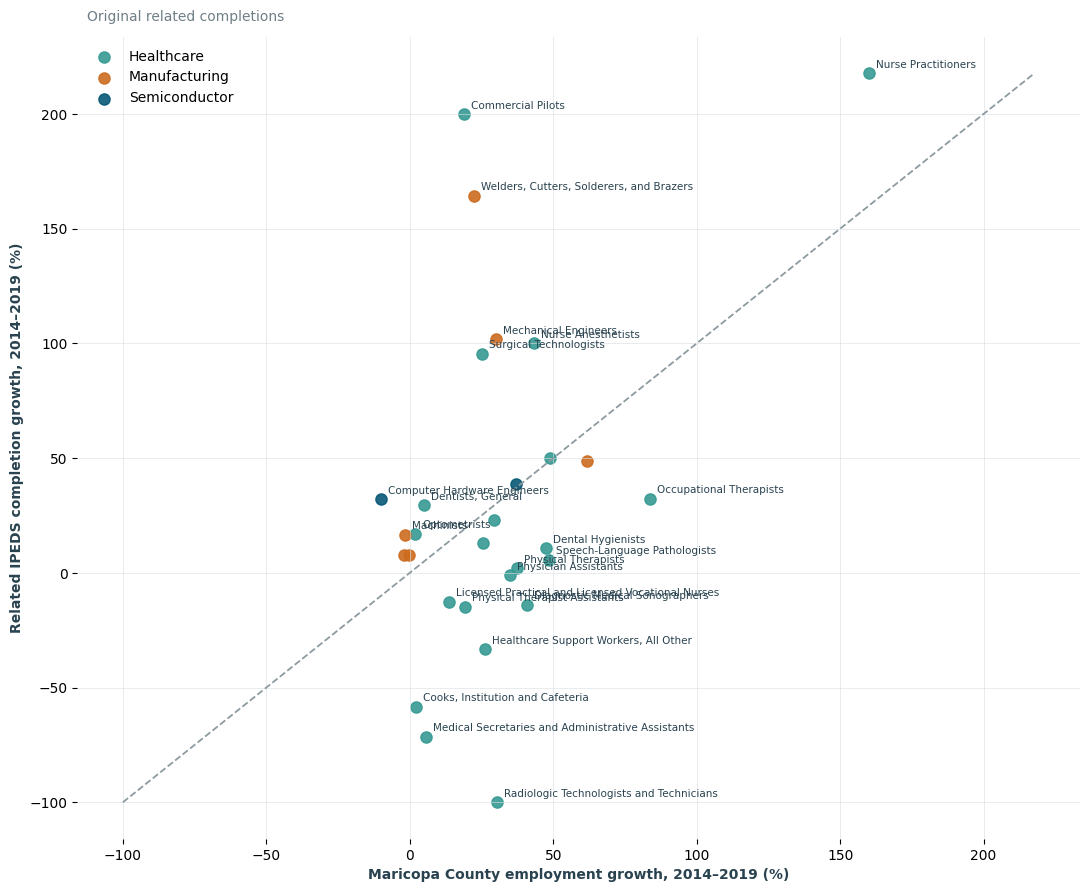

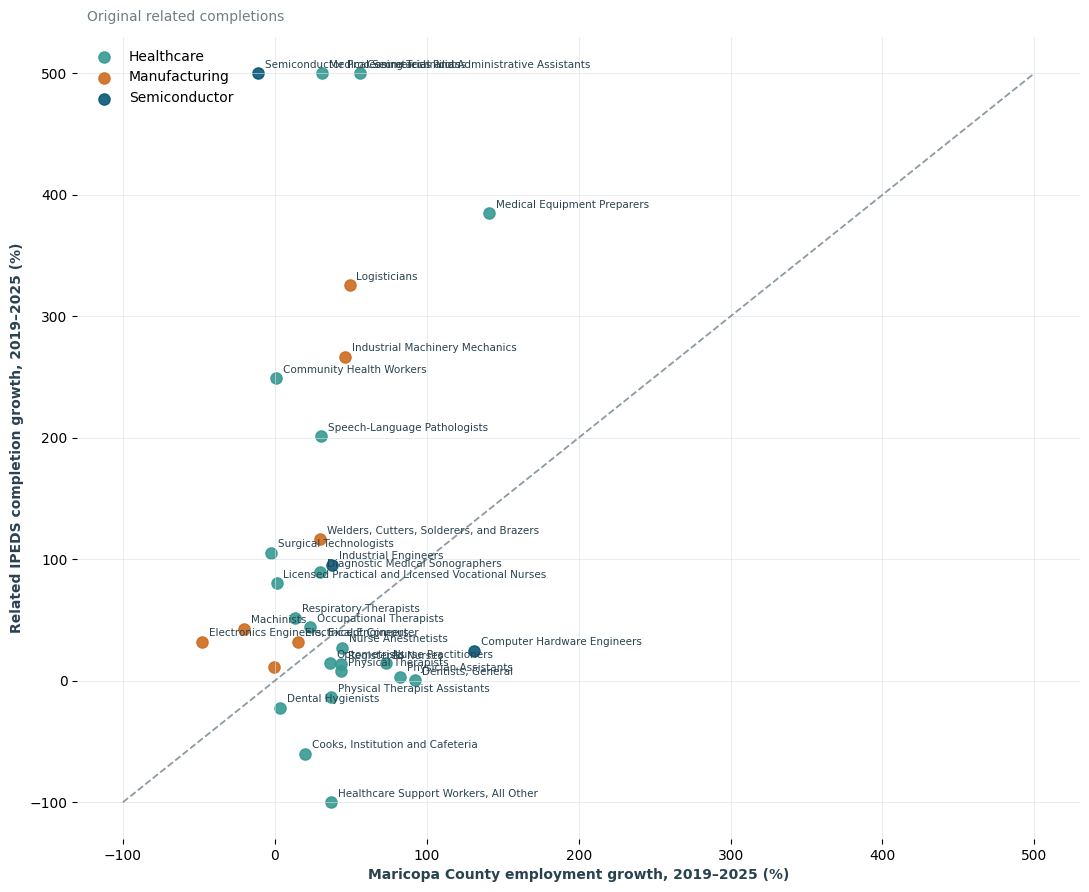

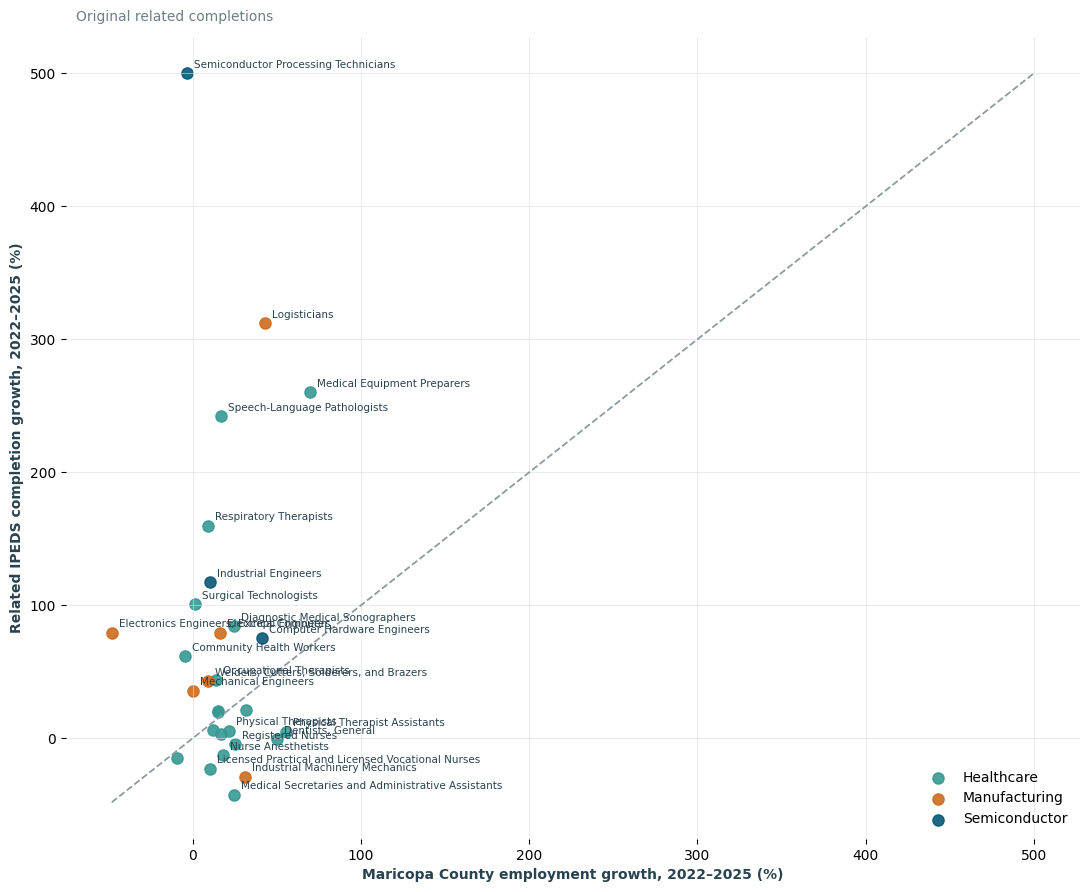

In [14]:
def scatter_period(tab, start, end, use_allocated=False, clip=500):
    ycol = "allocated_training_growth_pct" if use_allocated else "training_growth_pct"
    label = "Equal-allocation sensitivity" if use_allocated else "Original related completions"
    plot = tab.dropna(subset=["employment_growth_pct", ycol]).copy()
    plot["plot_x"] = plot["employment_growth_pct"].clip(-clip, clip)
    plot["plot_y"] = plot[ycol].clip(-clip, clip)

    fig, ax = plt.subplots(figsize=(11, 9))
    for group, color in [("Healthcare",HEALTHCARE),("Manufacturing",MANUFACTURING),("Semiconductor",SEMICONDUCTOR)]:
        t = plot[plot["display_group"].eq(group)]
        ax.scatter(t["plot_x"], t["plot_y"], s=65, color=color, label=group, alpha=.9)

    lo = min(plot["plot_x"].min(), plot["plot_y"].min(), 0)
    hi = max(plot["plot_x"].max(), plot["plot_y"].max(), 0)
    ax.plot([lo,hi],[lo,hi], linestyle="--", color="#8D9AA0", linewidth=1.3)

    for _, r in plot.iterrows():
        if abs((r[ycol] - r["employment_growth_pct"])) >= FLAG_PP:
            ax.annotate(r["occupation"], (r["plot_x"],r["plot_y"]), xytext=(5,4), textcoords="offset points", fontsize=7.5, color=TEXT)

    ax.set_xlabel(f"Maricopa County employment growth, {start}–{end} (%)", fontweight="bold", color=TEXT)
    ax.set_ylabel(f"Related IPEDS completion growth, {start}–{end} (%)", fontweight="bold", color=TEXT)
    ax.grid(color=GRID, linewidth=.7, alpha=.6)
    for s in ax.spines.values(): s.set_visible(False)
    ax.legend(frameon=False)
    ax.text(.01, 1.02, label, transform=ax.transAxes, fontsize=10, color="#6F7F86")
    plt.tight_layout()
    fn = FIGURE_DIR / f"IPEDS_validation_{start}_{end}_{'allocated' if use_allocated else 'original'}.png"
    plt.savefig(fn, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    return fn

figure_files = []
for start,end in PERIODS:
    figure_files.append(scatter_period(period_tables[f"{start}_{end}"], start, end, use_allocated=False))

## 14. Compact Ferris validation table

This is the table to review first. It shows whether each occupation is flagged the same way historically, in the main 2019→2025 period, and in the recent 2022→2025 period.

In [15]:
ferris_table = stability[[
    "sector","display_group","soc","occupation",
    "training_growth_14_19","employment_growth_14_19","gap_pp_14_19","flag_14_19",
    "training_growth_19_25","employment_growth_19_25","gap_pp_19_25","flag_19_25",
    "training_growth_22_25","employment_growth_22_25","gap_pp_22_25","flag_22_25",
    "temporal_pattern"
]].copy()

# Add crosswalk sensitivity / breadth context
ferris_table = ferris_table.merge(
    breadth_soc[["soc","n_related_cips","max_socs_from_any_related_cip","share_from_cips_6plus_pct","share_from_cips_10plus_pct","allocation_reduction_pct"]],
    on="soc", how="left"
)

# Whether original and allocated flags agree in each period
for start,end in PERIODS:
    t = period_tables[f"{start}_{end}"][["soc","flag_same_after_allocation"]].rename(columns={"flag_same_after_allocation":f"same_flag_after_allocation_{str(start)[-2:]}_{str(end)[-2:]}"})
    ferris_table = ferris_table.merge(t, on="soc", how="left")

ferris_table = ferris_table.sort_values(["temporal_pattern","sector","occupation"])
display(ferris_table)

,sector,display_group,soc,occupation,training_growth_14_19,employment_growth_14_19,gap_pp_14_19,flag_14_19,training_growth_19_25,employment_growth_19_25,gap_pp_19_25,flag_19_25,training_growth_22_25,employment_growth_22_25,gap_pp_22_25,flag_22_25,temporal_pattern,n_related_cips,max_socs_from_any_related_cip,share_from_cips_6plus_pct,share_from_cips_10plus_pct,allocation_reduction_pct,same_flag_after_allocation_14_19,same_flag_after_allocation_19_25,same_flag_after_allocation_22_25
11,Healthcare,Healthcare,29-1215,Family Medicine Physicians,NaN,13.638658,NaN,Insufficient baseline,NaN,-25.644260,NaN,Insufficient baseline,NaN,-20.757201,NaN,Insufficient baseline,Baseline limitation / review manually,3,1,NaN,NaN,NaN,True,True,True
22,Healthcare,Healthcare,35-3041,"Food Servers, Nonrestaurant",NaN,2.049492,NaN,Insufficient baseline,NaN,8.027811,NaN,Insufficient baseline,NaN,16.580022,NaN,Insufficient baseline,Baseline limitation / review manually,1,1,NaN,NaN,NaN,True,True,True
15,Healthcare,Healthcare,29-2035,Magnetic Resonance Imaging Technologists,NaN,29.068645,NaN,Insufficient baseline,NaN,-5.380885,NaN,Insufficient baseline,NaN,6.934855,NaN,Insufficient baseline,Baseline limitation / review manually,1,1,NaN,NaN,NaN,True,True,True
19,Healthcare,Healthcare,31-9093,Medical Equipment Preparers,NaN,31.132767,NaN,Insufficient baseline,384.615385,141.008340,243.607045,Related completions grew faster,260.000000,69.519366,190.480634,Related completions grew faster,Baseline limitation / review manually,1,2,0.0,0.0,50.000000,True,True,True
32,Manufacturing,Manufacturing,51-1011,First-Line Supervisors of Production and Opera...,NaN,-0.942358,NaN,Insufficient baseline,NaN,12.461602,NaN,Insufficient baseline,NaN,2.829707,NaN,Insufficient baseline,Baseline limitation / review manually,1,1,0.0,0.0,0.000000,True,True,True
33,Manufacturing,Manufacturing,51-4041,Machinists,16.666667,-1.536815,18.203482,Related completions grew faster,42.857143,-20.156548,63.013691,Related completions grew faster,NaN,-16.275144,NaN,Insufficient baseline,Baseline limitation / review manually,1,1,0.0,0.0,0.000000,True,True,True
35,Manufacturing,Semiconductor,51-9141,Semiconductor Processing Technicians,NaN,23.110368,NaN,Insufficient baseline,5700.000000,-10.961785,5710.961785,Related completions grew faster,8600.000000,-3.510863,8603.510863,Related completions grew faster,Baseline limitation / review manually,2,1,0.0,0.0,0.000000,True,True,True
21,Healthcare,Healthcare,35-2012,"Cooks, Institution and Cafeteria",-58.333333,2.237504,-60.570837,Employment grew faster,-60.000000,19.966118,-79.966118,Employment grew faster,20.000000,15.108131,4.891869,Roughly aligned,"Earlier divergence, not present recently",2,1,0.0,0.0,0.000000,True,True,True
12,Healthcare,Healthcare,29-1292,Dental Hygienists,10.687023,47.582296,-36.895273,Employment grew faster,-22.068966,3.577612,-25.646578,Employment grew faster,-15.037594,-9.594638,-5.442956,Roughly aligned,"Earlier divergence, not present recently",1,1,0.0,0.0,0.000000,True,True,True
13,Healthcare,Healthcare,29-2032,Diagnostic Medical Sonographers,-13.953488,41.021601,-54.975090,Employment grew faster,89.189189,29.786745,59.402445,Related completions grew faster,84.210526,24.750318,59.460208,Related completions grew faster,"Earlier divergence, not present recently",1,1,0.0,0.0,0.000000,True,True,True


## 15. Automatic QA summary — what can we safely say after running?

This cell does not write the narrative for you. It reports the validation facts you should inspect before deciding whether the original figure is robust.

In [16]:
print("="*72)
print("FERRIS VALIDATION CHECKLIST")
print("="*72)

print("\n1) CIP→SOC breadth")
print("   Maximum selected SOCs linked to one CIP:", int(cip_breadth["n_selected_socs"].max()))
print("   CIPs linked to 6+ selected SOCs:", int((cip_breadth["n_selected_socs"] >= 6).sum()))
print("   CIPs linked to 10+ selected SOCs:", int((cip_breadth["n_selected_socs"] >= 10).sum()))

print("\n2) Original vs equal-allocation sensitivity")
print(SENSITIVITY_SUMMARY.to_string(index=False))

print("\n3) Temporal patterns")
print(stability["temporal_pattern"].value_counts().to_string())

print("\n4) Occupations flagged 'Employment grew faster' by period")
for start,end in PERIODS:
    tab = period_tables[f"{start}_{end}"]
    names = tab.loc[tab["flag_original"].eq("Employment grew faster"), "occupation"].tolist()
    print(f"   {start}–{end}: {len(names)}")
    for name in names: print("      -", name)

print("\nReview the breadth and sensitivity tables before treating any occupation-level flag as robust.")

FERRIS VALIDATION CHECKLIST

1) CIP→SOC breadth
   Maximum selected SOCs linked to one CIP: 3
   CIPs linked to 6+ selected SOCs: 0
   CIPs linked to 10+ selected SOCs: 0

2) Original vs equal-allocation sensitivity
   period  occupations_with_both_baselines  same_flag_n  same_flag_pct  changed_flag_n
2014–2019                               29           29          100.0               0
2019–2025                               31           31          100.0               0
2022–2025                               29           29          100.0               0

3) Temporal patterns
temporal_pattern
Mixed / changing pattern                    13
Earlier divergence, not present recently     8
Baseline limitation / review manually        7
Recent employment-faster divergence          4
Persistent employment-faster divergence      2
Persistent completions-faster divergence     2

4) Occupations flagged 'Employment grew faster' by period
   2014–2019: 12
      - Physician Assistants
      - Oc

## 16. Export everything Ferris may need to inspect

In [17]:
README = pd.DataFrame({
    "Item": [
        "Purpose","Geography","Occupation universe","Periods","Original training measure","Sensitivity measure",
        "Growth gap","Descriptive flag","CIP breadth check","Interpretation caution"
    ],
    "Definition": [
        "Validate the existing IPEDS / occupation alignment figure before replication",
        "Maricopa County",
        "36 five-star Healthcare and Manufacturing detailed SOCs; Semiconductor is a subset of Manufacturing",
        "2014–2019, 2019–2025, 2022–2025",
        "Full related completions: a CIP's full completion count is associated with every selected SOC it maps to",
        "Equal allocation: a CIP's completions are divided equally across selected SOCs it maps to; sensitivity only",
        "Related-completion growth minus employment growth, percentage points",
        f"±{FLAG_PP} percentage points; descriptive only, not statistical significance or adequacy",
        "Counts selected SOCs per CIP and measures how much of each SOC's related completions comes from broadly mapped CIPs",
        "IPEDS completers are not verified entrants into mapped occupations; do not label gaps as shortages/surpluses"
    ]
})

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    README.to_excel(writer, sheet_name="README", index=False)
    ferris_table.to_excel(writer, sheet_name="FERRIS_VALIDATION", index=False)
    cip_breadth.to_excel(writer, sheet_name="CIP_BREADTH", index=False)
    breadth_soc.to_excel(writer, sheet_name="SOC_BREADTH_IMPACT", index=False)
    SENSITIVITY_SUMMARY.to_excel(writer, sheet_name="SENSITIVITY_SUMMARY", index=False)
    changed_flags.to_excel(writer, sheet_name="FLAGS_CHANGED_ALLOC", index=False)
    stability.to_excel(writer, sheet_name="TEMPORAL_STABILITY", index=False)
    period_long.to_excel(writer, sheet_name="ALL_PERIOD_RESULTS", index=False)
    period_tables["2014_2019"].to_excel(writer, sheet_name="PERIOD_2014_2019", index=False)
    period_tables["2019_2025"].to_excel(writer, sheet_name="PERIOD_2019_2025", index=False)
    period_tables["2022_2025"].to_excel(writer, sheet_name="PERIOD_2022_2025", index=False)
    soc_year.to_excel(writer, sheet_name="SOC_YEAR_LEVELS", index=False)
    relationships.to_excel(writer, sheet_name="CIP_SOC_RELATIONSHIPS", index=False)
    matched.to_excel(writer, sheet_name="MATCH_DETAIL", index=False)
    IPEDS_QA.to_excel(writer, sheet_name="IPEDS_QA", index=False)
    LIGHTCAST_QA.to_excel(writer, sheet_name="LIGHTCAST_QA", index=False)

    wb = writer.book
    for ws in wb.worksheets:
        ws.freeze_panes = "A2"
        ws.auto_filter.ref = ws.dimensions
        ws.sheet_view.showGridLines = False
        for cell in ws[1]:
            cell.font = cell.font.copy(bold=True)
        for col_cells in ws.columns:
            vals = [str(c.value) if c.value is not None else "" for c in col_cells[:200]]
            width = min(max(max((len(v) for v in vals), default=0)+2, 10), 42)
            ws.column_dimensions[col_cells[0].column_letter].width = width

print("Saved workbook:", OUTPUT_XLSX)
print("Saved figures to:", FIGURE_DIR)

Saved workbook: C:\Users\301533\Downloads\IPEDS_Method_Validation_Ferris.xlsx
Saved figures to: C:\Users\301533\Downloads\IPEDS_Method_Validation_Figures


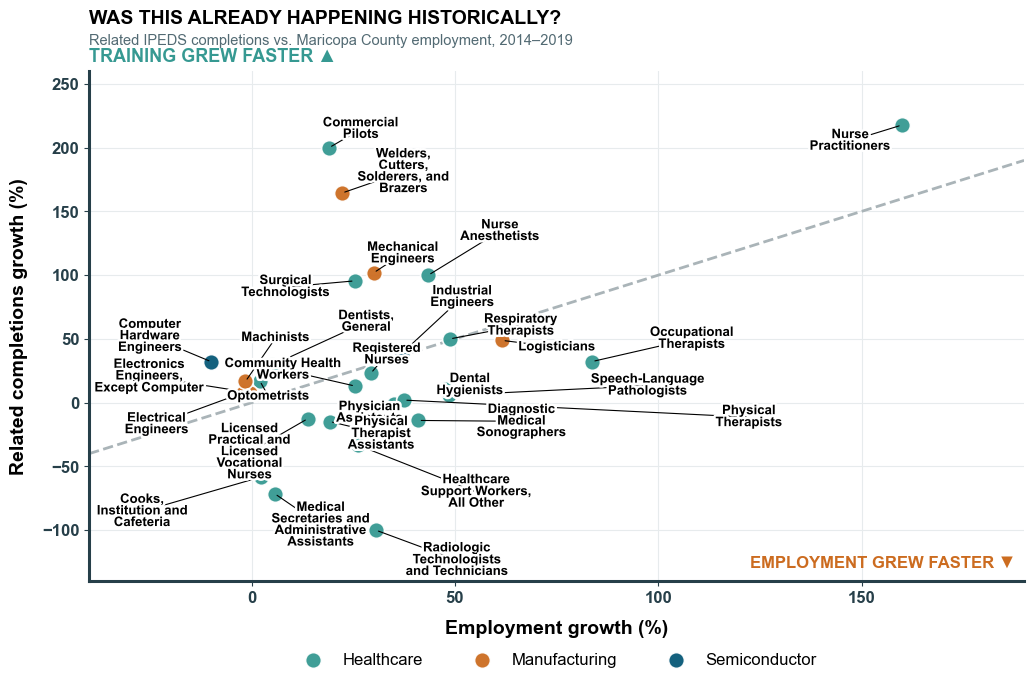

Saved: C:\Users\301533\Downloads\IPEDS_Method_Validation_Figures\Validation_2014_2019.png

Not displayed because they fall outside the presentation scale:
  • Medical Secretaries and Administrative Assistants
  • Commercial Pilots
  • Electronics Engineers, Except Computer
  • Semiconductor Processing Technicians


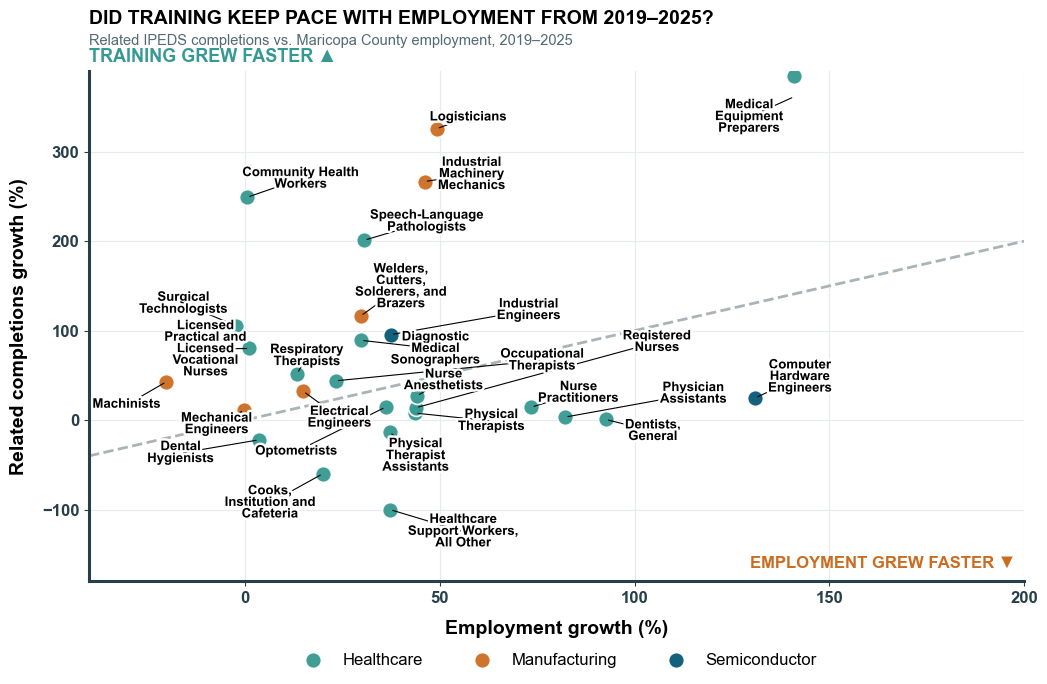

Saved: C:\Users\301533\Downloads\IPEDS_Method_Validation_Figures\Validation_2019_2025.png

Not displayed because they fall outside the presentation scale:
  • Speech-Language Pathologists
  • Medical Equipment Preparers
  • Logisticians
  • Electronics Engineers, Except Computer
  • Semiconductor Processing Technicians


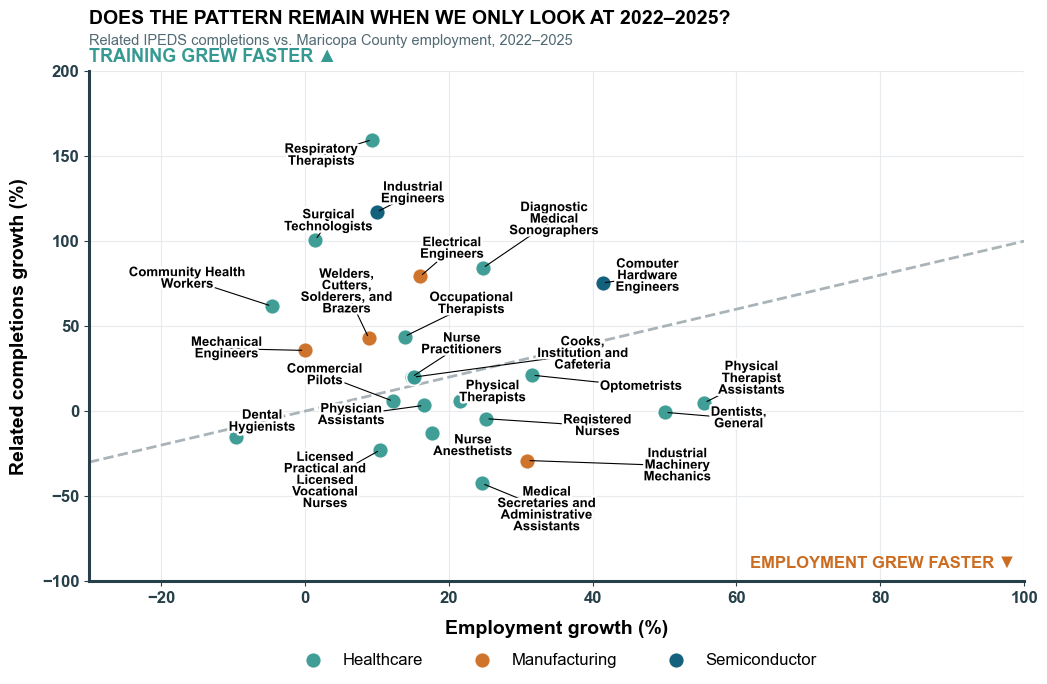

Saved: C:\Users\301533\Downloads\IPEDS_Method_Validation_Figures\Validation_2022_2025.png

KEEP GOING — all three validation figures created.


In [19]:
# =====================================================================
# VALIDATION FIGURES
# FULL REPLACEMENT GRAPHICS CELL
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from adjustText import adjust_text
import textwrap
from pathlib import Path


# =====================================================================
# COLORS
# =====================================================================

TEAL = "#369992"
ORANGE = "#CC6C20"
DARK_TURQUOISE = "#075877"

BLACK = "#000000"
GRAY = "#AAB4B8"
LIGHT_GRAY = "#E7EBED"
WHITE = "#FFFFFF"
DARK_AXIS = "#263F49"


SEMICONDUCTOR_OCCUPATIONS = [
    "Computer Hardware Engineers",
    "Industrial Engineers",
    "Semiconductor Processing Technicians"
]


# =====================================================================
# OUTPUT FOLDER
# =====================================================================

if "FIGURE_DIR" not in globals():

    FIGURE_DIR = (
        Path.cwd()
        / "Validation_Figures"
    )


FIGURE_DIR = Path(FIGURE_DIR)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# STYLE
# =====================================================================

plt.rcParams.update({

    "font.family": "Arial",

    "font.size": 12,

    "axes.labelsize": 15,

    "axes.labelweight": "bold",

    "xtick.labelsize": 12,

    "ytick.labelsize": 12,

    "axes.edgecolor": DARK_AXIS,

    "xtick.color": DARK_AXIS,

    "ytick.color": DARK_AXIS,

    "figure.facecolor": WHITE,

    "axes.facecolor": WHITE

})


# =====================================================================
# LABEL WRAPPING
# =====================================================================

def wrap_label(
    text,
    width=16
):

    return "\n".join(

        textwrap.wrap(

            str(text),

            width=width,

            break_long_words=False

        )

    )


# =====================================================================
# PREPARE PERIOD DATA
# =====================================================================

def prepare_period(
    period_name
):

    if period_name not in period_tables:

        raise KeyError(

            f"{period_name} not found.\n"
            f"Available periods: {list(period_tables.keys())}"

        )


    df = period_tables[
        period_name
    ].copy()


    # -------------------------------------------------------------
    # Find occupation column
    # -------------------------------------------------------------

    if "occupation" not in df.columns:

        for candidate in [

            "job_title",
            "Job Title",
            "SOC_Title",
            "occupation_title"

        ]:

            if candidate in df.columns:

                df = df.rename(
                    columns={
                        candidate:
                        "occupation"
                    }
                )

                break


    # -------------------------------------------------------------
    # Find sector column
    # -------------------------------------------------------------

    if "sector" not in df.columns:

        for candidate in [

            "Industry",
            "industry",
            "Sector"

        ]:

            if candidate in df.columns:

                df = df.rename(
                    columns={
                        candidate:
                        "sector"
                    }
                )

                break


    # -------------------------------------------------------------
    # Find employment growth column
    # -------------------------------------------------------------

    if "employment_growth_pct" not in df.columns:

        for candidate in [

            "jobs_growth_pct",
            "job_growth_pct",
            "employment_growth",
            "jobs_growth"

        ]:

            if candidate in df.columns:

                df = df.rename(
                    columns={
                        candidate:
                        "employment_growth_pct"
                    }
                )

                break


    # -------------------------------------------------------------
    # Find completion growth column
    # -------------------------------------------------------------

    if "related_growth_pct" not in df.columns:

        for candidate in [

            "related_completions_growth_pct",
            "training_growth_pct",
            "completion_growth_pct",
            "completions_growth_pct",
            "related_completion_growth_pct"

        ]:

            if candidate in df.columns:

                df = df.rename(
                    columns={
                        candidate:
                        "related_growth_pct"
                    }
                )

                break


    # -------------------------------------------------------------
    # Check columns
    # -------------------------------------------------------------

    required = [

        "occupation",
        "sector",
        "employment_growth_pct",
        "related_growth_pct"

    ]


    missing = [

        col

        for col in required

        if col not in df.columns

    ]


    if missing:

        print(
            "STOP — missing columns:",
            missing
        )

        print(
            "Available columns:",
            df.columns.tolist()
        )

        raise ValueError(
            "Required plotting columns missing."
        )


    # -------------------------------------------------------------
    # Numeric conversion
    # -------------------------------------------------------------

    df[
        "employment_growth_pct"
    ] = pd.to_numeric(

        df[
            "employment_growth_pct"
        ],

        errors="coerce"

    )


    df[
        "related_growth_pct"
    ] = pd.to_numeric(

        df[
            "related_growth_pct"
        ],

        errors="coerce"

    )


    # -------------------------------------------------------------
    # Valid growth values only
    # -------------------------------------------------------------

    df = df[

        np.isfinite(
            df[
                "employment_growth_pct"
            ]
        )

        &

        np.isfinite(
            df[
                "related_growth_pct"
            ]
        )

    ].copy()


    return df


# =====================================================================
# POINT COLOR
# =====================================================================

def point_color(
    row
):

    occupation = str(
        row["occupation"]
    ).strip()


    if occupation in SEMICONDUCTOR_OCCUPATIONS:

        return DARK_TURQUOISE


    if str(
        row["sector"]
    ).strip() == "Healthcare":

        return TEAL


    return ORANGE


# =====================================================================
# CREATE FIGURE
# =====================================================================

def create_validation_figure(

    df,

    filename,

    question,

    subtitle,

    x_limits,

    y_limits

):

    plot_df = df.copy()


    # =================================================================
    # PRESENTATION DISPLAY RANGE
    # =================================================================
    #
    # Keep the underlying analysis untouched.
    # Only occupations outside the specified visual range are omitted
    # from this presentation figure.
    # =================================================================

    inside = (

        plot_df[
            "employment_growth_pct"
        ].between(
            x_limits[0],
            x_limits[1]
        )

        &

        plot_df[
            "related_growth_pct"
        ].between(
            y_limits[0],
            y_limits[1]
        )

    )


    excluded = plot_df[
        ~inside
    ].copy()


    plot_df = plot_df[
        inside
    ].copy()


    if len(excluded) > 0:

        print(
            "\nNot displayed because they fall outside "
            "the presentation scale:"
        )

        for occupation in excluded[
            "occupation"
        ]:

            print(
                "  •",
                occupation
            )


    # =================================================================
    # COLORS
    # =================================================================

    plot_df[
        "point_color"
    ] = plot_df.apply(
        point_color,
        axis=1
    )


    # =================================================================
    # FIGURE
    # =================================================================

    fig, ax = plt.subplots(
        figsize=(
            11,
            7.5
        )
    )


    # =================================================================
    # REFERENCE LINE
    # =================================================================

    line_min = max(
        x_limits[0],
        y_limits[0]
    )


    line_max = min(
        x_limits[1],
        y_limits[1]
    )


    ax.plot(

        [
            line_min,
            line_max
        ],

        [
            line_min,
            line_max
        ],

        color=GRAY,

        linewidth=2,

        linestyle="--",

        zorder=1

    )


    # =================================================================
    # HEALTHCARE
    # =================================================================

    healthcare = plot_df[

        (
            plot_df[
                "sector"
            ]
            .astype(str)
            .str.strip()
            == "Healthcare"
        )

        &

        (
            ~plot_df[
                "occupation"
            ]
            .astype(str)
            .str.strip()
            .isin(
                SEMICONDUCTOR_OCCUPATIONS
            )
        )

    ]


    ax.scatter(

        healthcare[
            "employment_growth_pct"
        ],

        healthcare[
            "related_growth_pct"
        ],

        s=130,

        color=TEAL,

        edgecolor=WHITE,

        linewidth=1.2,

        alpha=.95,

        label="Healthcare",

        zorder=3

    )


    # =================================================================
    # MANUFACTURING
    # =================================================================

    manufacturing = plot_df[

        (
            plot_df[
                "sector"
            ]
            .astype(str)
            .str.strip()
            == "Manufacturing"
        )

        &

        (
            ~plot_df[
                "occupation"
            ]
            .astype(str)
            .str.strip()
            .isin(
                SEMICONDUCTOR_OCCUPATIONS
            )
        )

    ]


    ax.scatter(

        manufacturing[
            "employment_growth_pct"
        ],

        manufacturing[
            "related_growth_pct"
        ],

        s=130,

        color=ORANGE,

        edgecolor=WHITE,

        linewidth=1.2,

        alpha=.95,

        label="Manufacturing",

        zorder=3

    )


    # =================================================================
    # SEMICONDUCTOR
    # =================================================================

    semiconductor = plot_df[

        plot_df[
            "occupation"
        ]
        .astype(str)
        .str.strip()
        .isin(
            SEMICONDUCTOR_OCCUPATIONS
        )

    ]


    ax.scatter(

        semiconductor[
            "employment_growth_pct"
        ],

        semiconductor[
            "related_growth_pct"
        ],

        s=130,

        color=DARK_TURQUOISE,

        edgecolor=WHITE,

        linewidth=1.2,

        alpha=.95,

        label="Semiconductor",

        zorder=3

    )


    # =================================================================
    # SET LIMITS BEFORE LABEL PLACEMENT
    # =================================================================

    ax.set_xlim(
        x_limits
    )

    ax.set_ylim(
        y_limits
    )


    # =================================================================
    # OCCUPATION LABELS
    # =================================================================

    texts = []


    # Add an invisible padded boundary.
    #
    # This gives adjustText more reason to keep labels away
    # from the actual plot edges.

    x_padding = (
        x_limits[1]
        - x_limits[0]
    ) * .04


    y_padding = (
        y_limits[1]
        - y_limits[0]
    ) * .05


    label_x_min = (
        x_limits[0]
        + x_padding
    )

    label_x_max = (
        x_limits[1]
        - x_padding
    )


    label_y_min = (
        y_limits[0]
        + y_padding
    )

    label_y_max = (
        y_limits[1]
        - y_padding
    )


    for _, row in plot_df.iterrows():

        point_x = row[
            "employment_growth_pct"
        ]

        point_y = row[
            "related_growth_pct"
        ]


        # Starting label position is clipped inward.
        # The actual point remains at its true value.

        label_x = np.clip(

            point_x,

            label_x_min,

            label_x_max

        )


        label_y = np.clip(

            point_y,

            label_y_min,

            label_y_max

        )


        txt = ax.text(

            label_x,

            label_y,

            wrap_label(
                row["occupation"],
                width=16
            ),

            fontsize=9.5,

            fontweight="bold",

            color=BLACK,

            ha="center",

            va="center",

            linespacing=.95,

            zorder=5

        )


        txt.set_path_effects([

            path_effects.withStroke(

                linewidth=3.5,

                foreground=WHITE

            )

        ])


        texts.append(
            txt
        )


    # =================================================================
    # ADJUST LABELS
    # =================================================================

    adjust_text(

        texts,

        x=plot_df[
            "employment_growth_pct"
        ].to_numpy(),

        y=plot_df[
            "related_growth_pct"
        ].to_numpy(),

        ax=ax,

        only_move={
            "text": "xy",
            "static": "xy"
        },

        force_text=(
            1.3,
            1.6
        ),

        force_points=(
            2.0,
            2.5
        ),

        force_static=(
            1.0,
            1.2
        ),

        force_pull=(
            .002,
            .002
        ),

        expand=(
            1.20,
            1.30
        ),

        ensure_inside_axes=True,

        arrowprops=dict(

            arrowstyle="-",

            color=BLACK,

            linewidth=.8,

            alpha=1,

            zorder=4

        ),

        iter_lim=5000

    )


    # =================================================================
    # QUESTION / SUBTITLE
    # =================================================================

    ax.text(

        0,

        1.085,

        question,

        transform=ax.transAxes,

        fontsize=14,

        fontweight="bold",

        color=BLACK,

        ha="left",

        va="bottom"

    )


    ax.text(

        0,

        1.045,

        subtitle,

        transform=ax.transAxes,

        fontsize=10.5,

        color="#526A73",

        ha="left",

        va="bottom"

    )


    # =================================================================
    # INTERPRETATION LABELS
    # =================================================================

    ax.text(

        0,

        1.01,

        "TRAINING GREW FASTER ▲",

        transform=ax.transAxes,

        fontsize=13,

        fontweight="bold",

        color=TEAL,

        ha="left",

        va="bottom"

    )


    ax.text(

        .99,

        .02,

        "EMPLOYMENT GREW FASTER ▼",

        transform=ax.transAxes,

        fontsize=12,

        fontweight="bold",

        color=ORANGE,

        ha="right",

        va="bottom",

        zorder=6

    )


    # =================================================================
    # AXES
    # =================================================================

    ax.set_xlabel(

        "Employment growth (%)",

        labelpad=10,

        fontsize=14,

        fontweight="bold"

    )


    ax.set_ylabel(

        "Related completions growth (%)",

        labelpad=10,

        fontsize=14,

        fontweight="bold"

    )


    # =================================================================
    # GRID
    # =================================================================

    ax.grid(

        color=LIGHT_GRAY,

        linewidth=.8

    )


    ax.set_axisbelow(
        True
    )


    # =================================================================
    # SPINES
    # =================================================================

    ax.spines[
        "top"
    ].set_visible(
        False
    )


    ax.spines[
        "right"
    ].set_visible(
        False
    )


    ax.spines[
        "left"
    ].set_color(
        DARK_AXIS
    )


    ax.spines[
        "left"
    ].set_linewidth(
        2.2
    )


    ax.spines[
        "bottom"
    ].set_color(
        DARK_AXIS
    )


    ax.spines[
        "bottom"
    ].set_linewidth(
        2.2
    )


    # =================================================================
    # TICKS
    # =================================================================

    for tick in (

        ax.get_xticklabels()
        +

        ax.get_yticklabels()

    ):

        tick.set_fontweight(
            "bold"
        )


    # =================================================================
    # LEGEND
    # =================================================================

    ax.legend(

        frameon=False,

        loc="upper center",

        bbox_to_anchor=(
            .5,
            -.11
        ),

        ncol=3,

        columnspacing=2.5,

        fontsize=12,

        handletextpad=.8

    )


    # =================================================================
    # MARGINS
    # =================================================================

    fig.subplots_adjust(

        left=.11,

        right=.96,

        top=.84,

        bottom=.16

    )


    # =================================================================
    # SAVE
    # =================================================================

    output_path = (
        FIGURE_DIR
        /
        filename
    )


    fig.savefig(

        output_path,

        dpi=300,

        bbox_inches="tight",

        facecolor=WHITE

    )


    plt.show()


    print(
        "Saved:",
        output_path
    )


# =====================================================================
# PREPARE DATA
# =====================================================================

data_2014_2019 = prepare_period(
    "2014_2019"
)


data_2019_2025 = prepare_period(
    "2019_2025"
)


data_2022_2025 = prepare_period(
    "2022_2025"
)


# =====================================================================
# 2014–2019
# =====================================================================

create_validation_figure(

    df=data_2014_2019,

    filename=(
        "Validation_2014_2019.png"
    ),

    question=(
        "WAS THIS ALREADY HAPPENING HISTORICALLY?"
    ),

    subtitle=(
        "Related IPEDS completions vs. "
        "Maricopa County employment, 2014–2019"
    ),

    # Presentation bounds
    x_limits=(-40, 190),

    y_limits=(-140, 260)

)


# =====================================================================
# 2019–2025
# =====================================================================

create_validation_figure(

    df=data_2019_2025,

    filename=(
        "Validation_2019_2025.png"
    ),

    question=(
        "DID TRAINING KEEP PACE WITH EMPLOYMENT FROM 2019–2025?"
    ),

    subtitle=(
        "Related IPEDS completions vs. "
        "Maricopa County employment, 2019–2025"
    ),

    # Presentation bounds
    x_limits=(-40, 200),

    y_limits=(-180, 390)

)


# =====================================================================
# 2022–2025
# =====================================================================

create_validation_figure(

    df=data_2022_2025,

    filename=(
        "Validation_2022_2025.png"
    ),

    question=(
        "DOES THE PATTERN REMAIN WHEN WE ONLY LOOK AT 2022–2025?"
    ),

    subtitle=(
        "Related IPEDS completions vs. "
        "Maricopa County employment, 2022–2025"
    ),

    # Shorter period = naturally tighter scale
    x_limits=(-30, 100),

    y_limits=(-100, 200)

)


print(
    "\nKEEP GOING — all three validation figures created."
)

In [20]:
# =====================================================================
# WHICH OCCUPATIONS SHOW A PERSISTENT VS. RECENT PATTERN?
# =====================================================================

import pandas as pd
import numpy as np


# ---------------------------------------------------------------------
# Prepare each period
# ---------------------------------------------------------------------

p1 = prepare_period("2014_2019").copy()
p2 = prepare_period("2019_2025").copy()
p3 = prepare_period("2022_2025").copy()


# ---------------------------------------------------------------------
# Calculate the growth gap
#
# Negative:
# Employment grew faster than related completions
#
# Positive:
# Related completions grew faster than employment
# ---------------------------------------------------------------------

def add_gap(df, period):

    out = df[
        [
            "occupation",
            "sector",
            "employment_growth_pct",
            "related_growth_pct"
        ]
    ].copy()

    out["gap_pp"] = (
        out["related_growth_pct"]
        -
        out["employment_growth_pct"]
    )

    # Use ±15 percentage points as the descriptive threshold
    out["pattern"] = np.select(

        [
            out["gap_pp"] <= -15,
            out["gap_pp"] >= 15
        ],

        [
            "Employment grew faster",
            "Related completions grew faster"
        ],

        default="Broadly similar"
    )

    return out.rename(
        columns={
            "employment_growth_pct":
                f"employment_growth_{period}",

            "related_growth_pct":
                f"related_growth_{period}",

            "gap_pp":
                f"gap_{period}",

            "pattern":
                f"pattern_{period}"
        }
    )


a = add_gap(
    p1,
    "2014_2019"
)

b = add_gap(
    p2,
    "2019_2025"
)

c = add_gap(
    p3,
    "2022_2025"
)


# ---------------------------------------------------------------------
# Combine all periods
# ---------------------------------------------------------------------

comparison = (

    a.merge(
        b,
        on=[
            "occupation",
            "sector"
        ],
        how="outer"
    )

    .merge(
        c,
        on=[
            "occupation",
            "sector"
        ],
        how="outer"
    )

)


# ---------------------------------------------------------------------
# Classify the temporal pattern
# ---------------------------------------------------------------------

def classify_history(row):

    patterns = [
        row.get("pattern_2014_2019"),
        row.get("pattern_2019_2025"),
        row.get("pattern_2022_2025")
    ]

    valid = [
        x
        for x in patterns
        if pd.notna(x)
    ]


    employment_faster = sum(
        x == "Employment grew faster"
        for x in valid
    )

    training_faster = sum(
        x == "Related completions grew faster"
        for x in valid
    )

    similar = sum(
        x == "Broadly similar"
        for x in valid
    )


    # Persistent employment-faster pattern
    if (
        len(valid) >= 2
        and employment_faster == len(valid)
    ):

        return "Persistent employment-faster"


    # Persistent training-faster pattern
    if (
        len(valid) >= 2
        and training_faster == len(valid)
    ):

        return "Persistent training-faster"


    # Recent employment-faster
    if (
        row.get("pattern_2022_2025")
        == "Employment grew faster"
        and
        row.get("pattern_2014_2019")
        != "Employment grew faster"
    ):

        return "Recent employment-faster"


    # Recent training-faster
    if (
        row.get("pattern_2022_2025")
        == "Related completions grew faster"
        and
        row.get("pattern_2014_2019")
        != "Related completions grew faster"
    ):

        return "Recent training-faster"


    if similar == len(valid):

        return "Broadly similar over time"


    return "Mixed / changing"


comparison[
    "temporal_pattern"
] = comparison.apply(
    classify_history,
    axis=1
)


# ---------------------------------------------------------------------
# SORT
# ---------------------------------------------------------------------

sort_order = {

    "Persistent employment-faster": 1,

    "Recent employment-faster": 2,

    "Mixed / changing": 3,

    "Broadly similar over time": 4,

    "Recent training-faster": 5,

    "Persistent training-faster": 6

}


comparison[
    "_sort"
] = comparison[
    "temporal_pattern"
].map(
    sort_order
)


comparison = (

    comparison

    .sort_values(
        [
            "_sort",
            "gap_2022_2025"
        ],
        na_position="last"
    )

    .drop(
        columns="_sort"
    )

    .reset_index(
        drop=True
    )

)


# ---------------------------------------------------------------------
# DISPLAY THE IMPORTANT COLUMNS
# ---------------------------------------------------------------------

display_cols = [

    "occupation",
    "sector",

    "gap_2014_2019",
    "pattern_2014_2019",

    "gap_2019_2025",
    "pattern_2019_2025",

    "gap_2022_2025",
    "pattern_2022_2025",

    "temporal_pattern"

]


display(
    comparison[
        display_cols
    ].round(1)
)


# ---------------------------------------------------------------------
# SIMPLE SUMMARY
# ---------------------------------------------------------------------

print("\nSUMMARY")
print("=" * 70)

print(
    comparison[
        "temporal_pattern"
    ].value_counts()
)


print(
    "\n\nPERSISTENT EMPLOYMENT-FASTER OCCUPATIONS"
)

print("=" * 70)

persistent = comparison[
    comparison[
        "temporal_pattern"
    ]
    ==
    "Persistent employment-faster"
]


if len(persistent) == 0:

    print(
        "None meet the threshold in every available period."
    )

else:

    for _, row in persistent.iterrows():

        print(
            f"{row['occupation']}: "
            f"{row.get('gap_2014_2019', np.nan):.1f} pp | "
            f"{row.get('gap_2019_2025', np.nan):.1f} pp | "
            f"{row.get('gap_2022_2025', np.nan):.1f} pp"
        )


print(
    "\n\nRECENT EMPLOYMENT-FASTER OCCUPATIONS"
)

print("=" * 70)

recent = comparison[
    comparison[
        "temporal_pattern"
    ]
    ==
    "Recent employment-faster"
]


if len(recent) == 0:

    print(
        "None."
    )

else:

    for _, row in recent.iterrows():

        print(
            f"{row['occupation']}: "
            f"2022–2025 gap = "
            f"{row.get('gap_2022_2025', np.nan):.1f} pp"
        )

,occupation,sector,gap_2014_2019,pattern_2014_2019,gap_2019_2025,pattern_2019_2025,gap_2022_2025,pattern_2022_2025,temporal_pattern
0,Physical Therapist Assistants,Healthcare,-34.0,Employment grew faster,-50.4,Employment grew faster,-50.6,Employment grew faster,Persistent employment-faster
1,Physical Therapists,Healthcare,-35.5,Employment grew faster,-35.8,Employment grew faster,-15.9,Employment grew faster,Persistent employment-faster
2,"Healthcare Support Workers, All Other",Healthcare,-59.5,Employment grew faster,-137.2,Employment grew faster,NaN,NaN,Persistent employment-faster
3,Industrial Machinery Mechanics,Manufacturing,NaN,NaN,220.6,Related completions grew faster,-59.9,Employment grew faster,Recent employment-faster
4,"Dentists, General",Healthcare,24.4,Related completions grew faster,-91.9,Employment grew faster,-50.8,Employment grew faster,Recent employment-faster
5,Nurse Anesthetists,Healthcare,56.6,Related completions grew faster,-17.1,Employment grew faster,-30.6,Employment grew faster,Recent employment-faster
6,Registered Nurses,Healthcare,-6.2,Broadly similar,-30.1,Employment grew faster,-29.6,Employment grew faster,Recent employment-faster
7,Medical Secretaries and Administrative Assistants,Healthcare,-77.1,Employment grew faster,635.5,Related completions grew faster,-67.1,Employment grew faster,Mixed / changing
8,Licensed Practical and Licensed Vocational Nurses,Healthcare,-26.4,Employment grew faster,79.0,Related completions grew faster,-33.3,Employment grew faster,Mixed / changing
9,Physician Assistants,Healthcare,-36.1,Employment grew faster,-78.8,Employment grew faster,-13.1,Broadly similar,Mixed / changing



SUMMARY
temporal_pattern
Mixed / changing                11
Recent training-faster           9
Persistent training-faster       5
Recent employment-faster         4
Persistent employment-faster     3
Name: count, dtype: int64


PERSISTENT EMPLOYMENT-FASTER OCCUPATIONS
Physical Therapist Assistants: -34.0 pp | -50.4 pp | -50.6 pp
Physical Therapists: -35.5 pp | -35.8 pp | -15.9 pp
Healthcare Support Workers, All Other: -59.5 pp | -137.2 pp | nan pp


RECENT EMPLOYMENT-FASTER OCCUPATIONS
Industrial Machinery Mechanics: 2022–2025 gap = -59.9 pp
Dentists, General: 2022–2025 gap = -50.8 pp
Nurse Anesthetists: 2022–2025 gap = -30.6 pp
Registered Nurses: 2022–2025 gap = -29.6 pp


In [21]:
print(OUTPUT_XLSX)

C:\Users\301533\Downloads\IPEDS_Method_Validation_Ferris.xlsx


In [22]:
# ============================================================
# FULL CIP → SOC BREADTH CHECK
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. USE THE FULL CIP-SOC CROSSWALK
# ------------------------------------------------------------
# Change this ONLY if your crosswalk has a different variable name.
# It must contain ALL CIP→SOC relationships, not just the selected
# Healthcare/Manufacturing occupations.

print("Available relationship columns:")
print(relationships.columns.tolist())


# ------------------------------------------------------------
# 2. FIND CIP AND SOC COLUMNS
# ------------------------------------------------------------

def find_col(df, possibilities):
    lookup = {str(c).lower().strip(): c for c in df.columns}

    for name in possibilities:
        if name.lower().strip() in lookup:
            return lookup[name.lower().strip()]

    for c in df.columns:
        cl = str(c).lower()
        if any(name.lower() in cl for name in possibilities):
            return c

    return None


cip_col = find_col(
    relationships,
    ["CIP_Code", "CIP Code", "CIP", "CIP2020Code"]
)

soc_col = find_col(
    relationships,
    ["SOC_Code", "SOC Code", "SOC", "SOC2018Code"]
)

print("\nDetected:")
print("CIP:", cip_col)
print("SOC:", soc_col)

if cip_col is None or soc_col is None:
    raise ValueError(
        "Could not identify the CIP and SOC columns. "
        "Look at the printed column names above."
    )


# ------------------------------------------------------------
# 3. CLEAN CODES
# ------------------------------------------------------------

rel = relationships[[cip_col, soc_col]].copy()

rel["cip"] = (
    rel[cip_col]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.strip()
)

rel["soc"] = (
    rel[soc_col]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.strip()
)

rel = rel[
    (~rel["cip"].isin(["", "nan", "None"])) &
    (~rel["soc"].isin(["", "nan", "None"]))
].drop_duplicates()


# ------------------------------------------------------------
# 4. COUNT ALL SOC DESTINATIONS FOR EACH CIP
# ------------------------------------------------------------

full_cip_breadth = (
    rel.groupby("cip")["soc"]
    .nunique()
    .reset_index(name="total_soc_destinations")
)

print("\nFULL CROSSWALK CIP BREADTH")
print(full_cip_breadth["total_soc_destinations"].describe())


# ------------------------------------------------------------
# 5. ATTACH FULL BREADTH TO OUR SELECTED OCCUPATION-CIP PAIRS
# ------------------------------------------------------------

selected_pairs = matched.copy()

selected_cip_col = find_col(
    selected_pairs,
    ["CIP_Code", "CIP Code", "CIP"]
)

selected_soc_col = find_col(
    selected_pairs,
    ["SOC_Code", "SOC Code", "SOC"]
)

selected_occ_col = find_col(
    selected_pairs,
    ["Job Title", "SOC_Title", "occupation"]
)

selected_pairs["cip_clean"] = (
    selected_pairs[selected_cip_col]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.strip()
)

selected_pairs["soc_clean"] = (
    selected_pairs[selected_soc_col]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.strip()
)

selected_pairs = selected_pairs.merge(
    full_cip_breadth,
    left_on="cip_clean",
    right_on="cip",
    how="left"
)


# ------------------------------------------------------------
# 6. SUMMARIZE BREADTH FOR EACH OF OUR OCCUPATIONS
# ------------------------------------------------------------

soc_full_breadth = (
    selected_pairs
    .groupby(
        ["soc_clean", selected_occ_col],
        dropna=False
    )
    .agg(
        number_related_cips=("cip_clean", "nunique"),
        median_soc_destinations=("total_soc_destinations", "median"),
        max_soc_destinations=("total_soc_destinations", "max"),
        min_soc_destinations=("total_soc_destinations", "min")
    )
    .reset_index()
)

soc_full_breadth = soc_full_breadth.sort_values(
    "max_soc_destinations",
    ascending=False
)

print("\n" + "=" * 80)
print("FULL CROSSWALK BREADTH BY SELECTED OCCUPATION")
print("=" * 80)

display(soc_full_breadth)


# ------------------------------------------------------------
# 7. FLAG POTENTIALLY BROAD CIP MAPPINGS
# ------------------------------------------------------------

soc_full_breadth["breadth_flag"] = np.select(
    [
        soc_full_breadth["max_soc_destinations"] >= 20,
        soc_full_breadth["max_soc_destinations"] >= 10,
        soc_full_breadth["max_soc_destinations"] >= 5
    ],
    [
        "VERY BROAD (20+ SOCs)",
        "BROAD (10–19 SOCs)",
        "MODERATELY BROAD (5–9 SOCs)"
    ],
    default="NARROW (<5 SOCs)"
)

print("\nBREADTH FLAGS")
print("=" * 80)

display(
    soc_full_breadth[
        [
            "soc_clean",
            selected_occ_col,
            "number_related_cips",
            "median_soc_destinations",
            "max_soc_destinations",
            "breadth_flag"
        ]
    ]
)


# ------------------------------------------------------------
# 8. SPECIFICALLY CHECK SEMICONDUCTOR PROCESSING TECHNICIANS
# ------------------------------------------------------------

semi = selected_pairs[
    selected_pairs[selected_occ_col]
    .astype(str)
    .str.contains(
        "Semiconductor Processing",
        case=False,
        na=False
    )
][
    [
        "soc_clean",
        selected_occ_col,
        "cip_clean",
        "total_soc_destinations"
    ]
].drop_duplicates()

print("\n" + "=" * 80)
print("SEMICONDUCTOR PROCESSING TECHNICIANS — FULL CROSSWALK CHECK")
print("=" * 80)

display(
    semi.sort_values(
        "total_soc_destinations",
        ascending=False
    )
)


# ------------------------------------------------------------
# 9. QUICK ANSWER
# ------------------------------------------------------------

broad_share = (
    soc_full_breadth["max_soc_destinations"] >= 10
).mean() * 100

print("\n" + "=" * 80)
print("QUICK SUMMARY")
print("=" * 80)

print(
    f"{broad_share:.1f}% of selected occupations have at least "
    "one related CIP that maps to 10+ SOCs in the full crosswalk."
)

print(
    "\nSend me the BREADTH FLAGS table and the "
    "SEMICONDUCTOR PROCESSING TECHNICIANS table."
)

Available relationship columns:
['sector', 'soc', 'occupation', 'cip_title', 'cip_current']

Detected:
CIP: cip_title
SOC: soc

FULL CROSSWALK CIP BREADTH
count    59.000000
mean      1.084746
std       0.336725
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: total_soc_destinations, dtype: float64

FULL CROSSWALK BREADTH BY SELECTED OCCUPATION


,soc_clean,occupation,number_related_cips,median_soc_destinations,max_soc_destinations,min_soc_destinations
1,17-2061,Computer Hardware Engineers,3,2.0,3,1
2,17-2071,Electrical Engineers,3,3.0,3,2
3,17-2072,"Electronics Engineers, Except Computer",1,3.0,3,3
5,17-2141,Mechanical Engineers,3,1.0,2,1
25,31-9093,Medical Equipment Preparers,1,2.0,2,2
22,29-2055,Surgical Technologists,3,1.0,2,1
0,13-1081,Logisticians,1,1.0,1,1
4,17-2112,Industrial Engineers,4,1.0,1,1
8,29-1041,Optometrists,1,1.0,1,1
9,29-1071,Physician Assistants,2,1.0,1,1



BREADTH FLAGS


,soc_clean,occupation,number_related_cips,median_soc_destinations,max_soc_destinations,breadth_flag
1,17-2061,Computer Hardware Engineers,3,2.0,3,NARROW (<5 SOCs)
2,17-2071,Electrical Engineers,3,3.0,3,NARROW (<5 SOCs)
3,17-2072,"Electronics Engineers, Except Computer",1,3.0,3,NARROW (<5 SOCs)
5,17-2141,Mechanical Engineers,3,1.0,2,NARROW (<5 SOCs)
25,31-9093,Medical Equipment Preparers,1,2.0,2,NARROW (<5 SOCs)
22,29-2055,Surgical Technologists,3,1.0,2,NARROW (<5 SOCs)
0,13-1081,Logisticians,1,1.0,1,NARROW (<5 SOCs)
4,17-2112,Industrial Engineers,4,1.0,1,NARROW (<5 SOCs)
8,29-1041,Optometrists,1,1.0,1,NARROW (<5 SOCs)
9,29-1071,Physician Assistants,2,1.0,1,NARROW (<5 SOCs)



SEMICONDUCTOR PROCESSING TECHNICIANS — FULL CROSSWALK CHECK


,soc_clean,occupation,cip_clean,total_soc_destinations
169,51-9141,Semiconductor Processing Technicians,Semiconductor Manufacturing Technology/Technic...,1
170,51-9141,Semiconductor Processing Technicians,Industrial Electronics Technology/Technician.,1



QUICK SUMMARY
0.0% of selected occupations have at least one related CIP that maps to 10+ SOCs in the full crosswalk.

Send me the BREADTH FLAGS table and the SEMICONDUCTOR PROCESSING TECHNICIANS table.


In [23]:
# =====================================================================
# BROADER CIP → SOC MAPPING CHECK
# Uses ALL occupation ratings (1–5 stars)
# =====================================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------
# FILE
# ---------------------------------------------------------------------

MASTER_ALL_RATINGS = Path(
    r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart"
    r"\Master_CIP_SOC_Matched_Output_2 (1).xlsx"
)

SHEET = "Master_Matched_Data"

# ---------------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------------

df = pd.read_excel(
    MASTER_ALL_RATINGS,
    sheet_name=SHEET
)

print("Rows loaded:", len(df))
print("Unique SOCs:", df["SOC_Code"].nunique())
print("Unique CIPs:", df["CIP_Code"].nunique())

# ---------------------------------------------------------------------
# CLEAN CODES
# ---------------------------------------------------------------------

def clean_code(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().replace("'", "")

    if x.endswith(".0"):
        x = x[:-2]

    return x


df["soc_clean"] = df["SOC_Code"].apply(clean_code)
df["cip_clean"] = df["CIP_Code"].apply(clean_code)

# ---------------------------------------------------------------------
# ALL UNIQUE CIP → SOC RELATIONSHIPS
# ACROSS RATINGS 1–5
# ---------------------------------------------------------------------

all_relationships = (
    df[
        [
            "cip_clean",
            "CIP_Title",
            "soc_clean",
            "SOC_Title"
        ]
    ]
    .dropna(subset=["cip_clean", "soc_clean"])
    .drop_duplicates(subset=["cip_clean", "soc_clean"])
)

print("\n" + "=" * 75)
print("BROADER MASTER UNIVERSE")
print("=" * 75)

print("Unique CIPs:", all_relationships["cip_clean"].nunique())
print("Unique SOCs:", all_relationships["soc_clean"].nunique())
print("Unique CIP-SOC relationships:", len(all_relationships))

# ---------------------------------------------------------------------
# COUNT HOW MANY SOCs EACH CIP MAPS TO
# ---------------------------------------------------------------------

cip_breadth = (
    all_relationships
    .groupby("cip_clean")
    .agg(
        total_soc_destinations=("soc_clean", "nunique")
    )
    .reset_index()
)

# ---------------------------------------------------------------------
# IDENTIFY THE FIVE-STAR OCCUPATIONS
# ---------------------------------------------------------------------

five_star = df[
    pd.to_numeric(
        df["Occupation Rating (1-5 Stars)"],
        errors="coerce"
    ).eq(5)
].copy()

five_star_socs = set(
    five_star["soc_clean"]
    .dropna()
    .unique()
)

print("\nFive-star SOCs found:", len(five_star_socs))

# ---------------------------------------------------------------------
# FIND CIPs ASSOCIATED WITH THE FIVE-STAR OCCUPATIONS
# ---------------------------------------------------------------------

five_star_relationships = (
    all_relationships[
        all_relationships["soc_clean"].isin(five_star_socs)
    ]
    .merge(
        cip_breadth,
        on="cip_clean",
        how="left"
    )
)

# ---------------------------------------------------------------------
# SUMMARIZE BREADTH FOR EACH FIVE-STAR OCCUPATION
# ---------------------------------------------------------------------

soc_breadth = (
    five_star_relationships
    .groupby(
        ["soc_clean", "SOC_Title"],
        dropna=False
    )
    .agg(
        related_cips=("cip_clean", "nunique"),
        median_soc_destinations=("total_soc_destinations", "median"),
        max_soc_destinations=("total_soc_destinations", "max")
    )
    .reset_index()
)

soc_breadth["mapping_flag"] = np.select(
    [
        soc_breadth["max_soc_destinations"] >= 10,
        soc_breadth["max_soc_destinations"] >= 5,
        soc_breadth["max_soc_destinations"] >= 2
    ],
    [
        "VERY BROAD: 10+ SOCs",
        "BROAD: 5-9 SOCs",
        "MULTIPLE: 2-4 SOCs"
    ],
    default="ONE-TO-ONE"
)

soc_breadth = (
    soc_breadth
    .sort_values(
        ["max_soc_destinations", "median_soc_destinations"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 75)
print("BREADTH OF CIPs USED BY FIVE-STAR OCCUPATIONS")
print("=" * 75)

display(soc_breadth)

# ---------------------------------------------------------------------
# SHOW ONLY CIPs THAT MAP TO MULTIPLE OCCUPATIONS
# ---------------------------------------------------------------------

broad_cips = (
    five_star_relationships[
        five_star_relationships["total_soc_destinations"] > 1
    ][
        [
            "soc_clean",
            "SOC_Title",
            "cip_clean",
            "CIP_Title",
            "total_soc_destinations"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "total_soc_destinations",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 75)
print("FIVE-STAR OCCUPATIONS WITH MULTI-SOC CIPs")
print("=" * 75)

if len(broad_cips) == 0:
    print("None.")
else:
    display(broad_cips)

# ---------------------------------------------------------------------
# SEMICONDUCTOR PROCESSING TECHNICIANS
# ---------------------------------------------------------------------

semi = five_star_relationships[
    five_star_relationships["SOC_Title"]
    .astype(str)
    .str.contains(
        "Semiconductor Processing",
        case=False,
        na=False
    )
][
    [
        "soc_clean",
        "SOC_Title",
        "cip_clean",
        "CIP_Title",
        "total_soc_destinations"
    ]
].drop_duplicates()

print("\n" + "=" * 75)
print("SEMICONDUCTOR PROCESSING TECHNICIANS")
print("=" * 75)

display(semi)

# ---------------------------------------------------------------------
# SHOW EVERY SOC THAT THOSE SEMICONDUCTOR CIPs CONNECT TO
# ---------------------------------------------------------------------

semi_cips = semi["cip_clean"].dropna().unique()

semi_destinations = (
    all_relationships[
        all_relationships["cip_clean"].isin(semi_cips)
    ]
    .merge(
        cip_breadth,
        on="cip_clean",
        how="left"
    )
    .sort_values(
        ["cip_clean", "soc_clean"]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 75)
print("ALL OCCUPATIONS CONNECTED TO SEMICONDUCTOR CIPs")
print("=" * 75)

display(semi_destinations)

# ---------------------------------------------------------------------
# QUICK SUMMARY
# ---------------------------------------------------------------------

n_total = len(soc_breadth)
n_multiple = (soc_breadth["max_soc_destinations"] > 1).sum()
n_5plus = (soc_breadth["max_soc_destinations"] >= 5).sum()
n_10plus = (soc_breadth["max_soc_destinations"] >= 10).sum()

print("\n" + "=" * 75)
print("QUICK SUMMARY")
print("=" * 75)

print(f"Five-star occupations checked: {n_total}")

print(
    f"At least one CIP maps to multiple occupations: "
    f"{n_multiple} of {n_total} "
    f"({n_multiple / n_total * 100:.1f}%)"
)

print(
    f"At least one CIP maps to 5+ occupations: "
    f"{n_5plus} of {n_total} "
    f"({n_5plus / n_total * 100:.1f}%)"
)

print(
    f"At least one CIP maps to 10+ occupations: "
    f"{n_10plus} of {n_total} "
    f"({n_10plus / n_total * 100:.1f}%)"
)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Arielle\\Desktop\\Desktop\\New folder\\Walmart\\Master_CIP_SOC_Matched_Output_2 (1).xlsx'

In [ ]:
# ============================================================
# SEMICONDUCTOR PROCESSING TECHNICIANS — CHECK ACTUAL COUNTS
# ============================================================

semi_check = soc_year[
    soc_year["occupation"]
    .astype(str)
    .str.contains(
        "Semiconductor Processing",
        case=False,
        na=False
    )
].copy()

cols = [
    c for c in [
        "year",
        "soc",
        "occupation",
        "related_completions",
        "allocated_completions",
        "employment"
    ]
    if c in semi_check.columns
]

semi_check = (
    semi_check[cols]
    .sort_values("year")
    .reset_index(drop=True)
)

print("=" * 70)
print("SEMICONDUCTOR PROCESSING TECHNICIANS — ACTUAL COUNTS")
print("=" * 70)

display(semi_check)

SEMICONDUCTOR PROCESSING TECHNICIANS — ACTUAL COUNTS


,year,soc,occupation,related_completions,allocated_completions
0,2014,51-9141,Semiconductor Processing Technicians,0.0,0.0
1,2019,51-9141,Semiconductor Processing Technicians,3.0,3.0
2,2022,51-9141,Semiconductor Processing Technicians,2.0,2.0
3,2025,51-9141,Semiconductor Processing Technicians,174.0,174.0


Using columns:
Occupation: occupation
Year: year
Related completions: related_completions
Employment: jobs

KEEP GOING — all selected occupations found.

ACTUAL VALUES USED IN LONGITUDINAL FIGURE


,occupation,year,jobs,related_completions,employment_index,completion_index
12,Dental Hygienists,2014,2135.5,131.0,100.0,100.0
13,Dental Hygienists,2019,3151.7,145.0,147.6,110.7
14,Dental Hygienists,2022,3610.9,133.0,169.1,101.5
15,Dental Hygienists,2025,3264.4,113.0,152.9,86.3
24,Diagnostic Medical Sonographers,2014,923.4,43.0,100.0,100.0
25,Diagnostic Medical Sonographers,2019,1302.2,37.0,141.0,86.0
26,Diagnostic Medical Sonographers,2022,1354.7,38.0,146.7,88.4
27,Diagnostic Medical Sonographers,2025,1690.0,70.0,183.0,162.8
28,Industrial Engineers,2014,2974.9,145.0,100.0,100.0
29,Industrial Engineers,2019,4072.8,201.0,136.9,138.6



Shared y-axis: 0 to 500


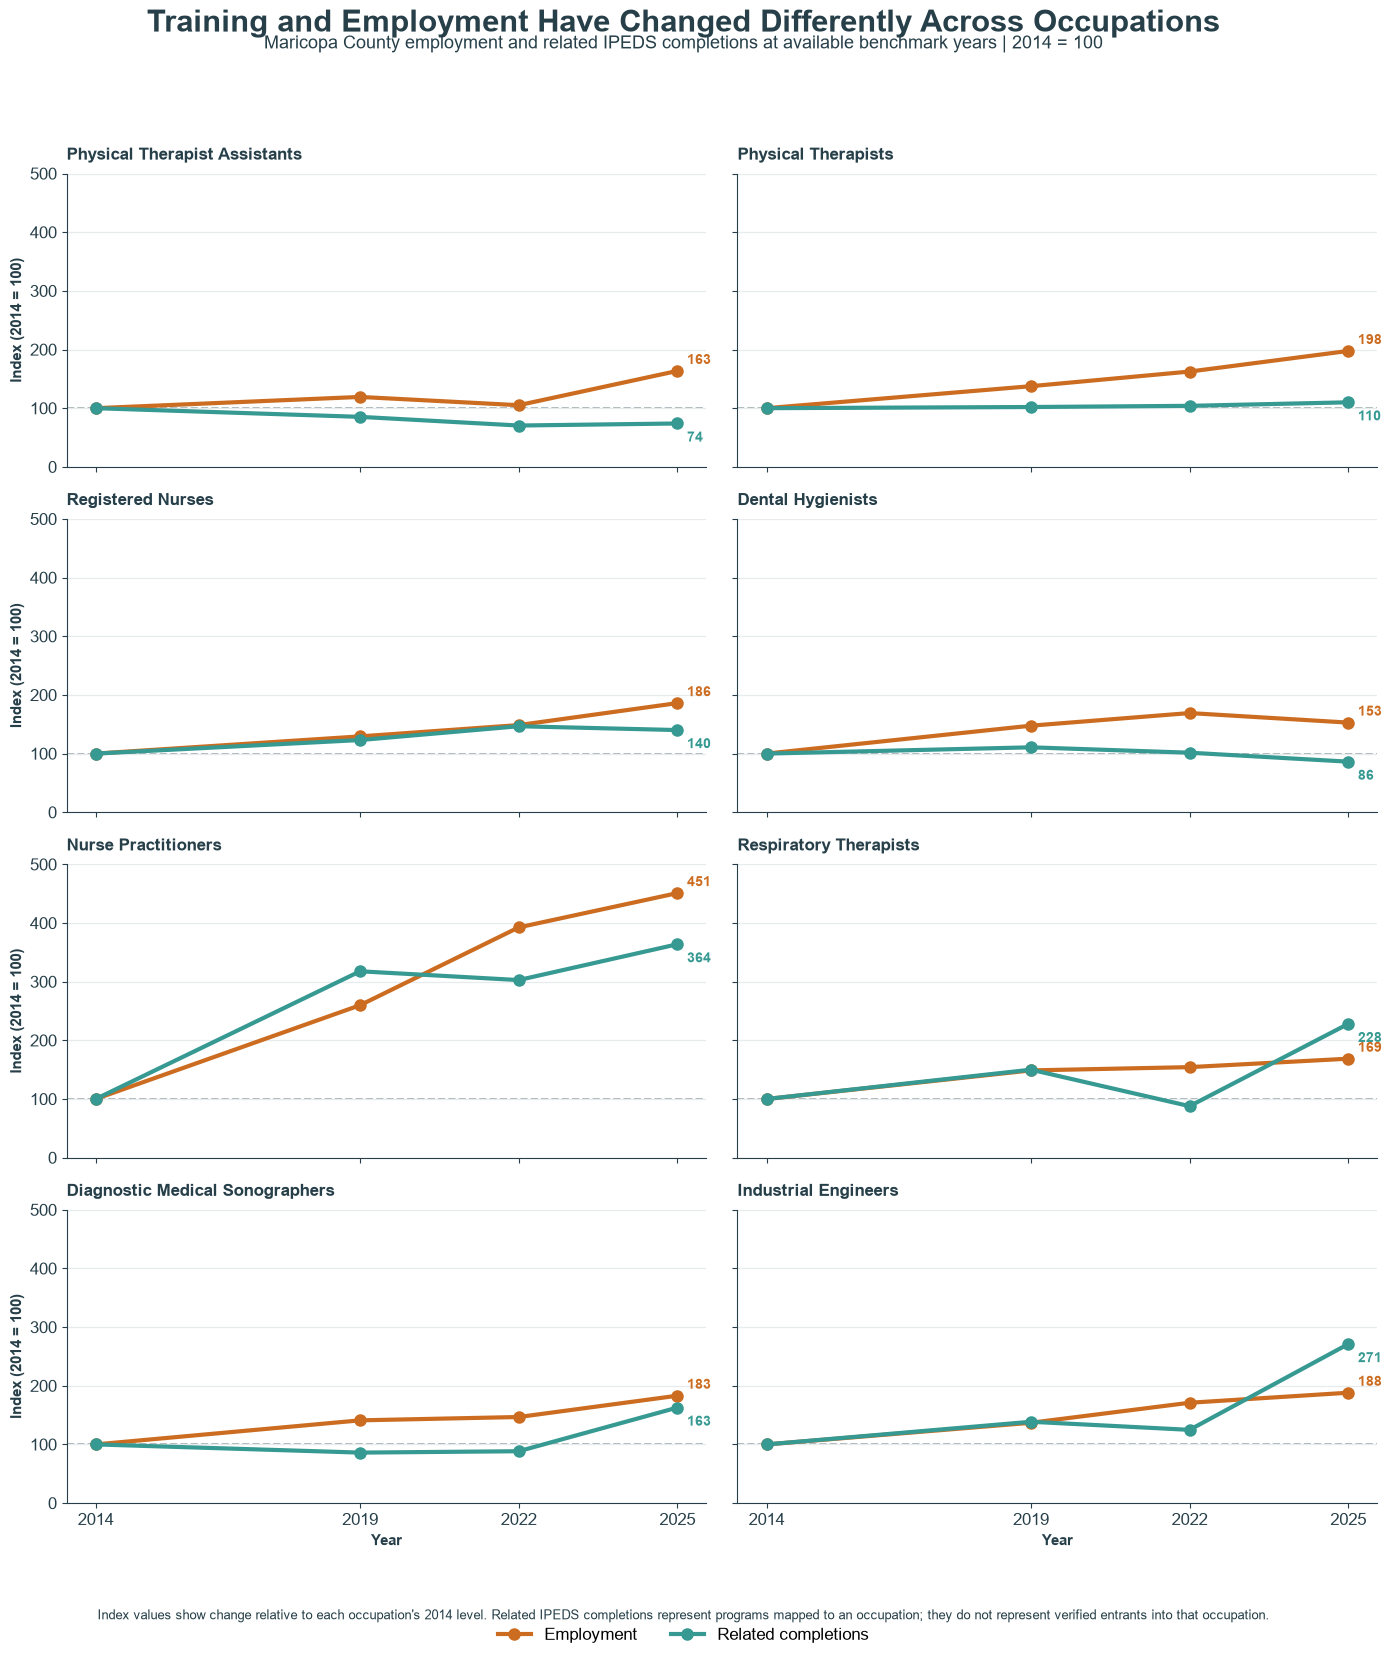

In [ ]:
# ============================================================
# LONGITUDINAL SMALL MULTIPLES
# Employment vs. Related IPEDS Completions
# Benchmark years: 2014, 2019, 2022, 2025
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# ------------------------------------------------------------
# STYLE
# ------------------------------------------------------------

TEAL = "#369992"          # Related completions
ORANGE = "#CC6C20"        # Employment
DARK_AXIS = "#263F49"
GRAY = "#AAB4B8"
LIGHT_GRAY = "#E7EBED"
WHITE = "#FFFFFF"
BLACK = "#000000"

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11
})

# ------------------------------------------------------------
# 1. OCCUPATIONS TO SHOW
# ------------------------------------------------------------

selected_occupations = [
    "Physical Therapist Assistants",
    "Physical Therapists",
    "Registered Nurses",
    "Dental Hygienists",
    "Nurse Practitioners",
    "Respiratory Therapists",
    "Diagnostic Medical Sonographers",
    "Industrial Engineers",
]

years = [2014, 2019, 2022, 2025]


# ------------------------------------------------------------
# 2. FIND THE NEEDED COLUMNS
# ------------------------------------------------------------

def find_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


occupation_col = find_column(
    soc_year,
    ["occupation", "SOC_Title", "Job Title"]
)

year_col = find_column(
    soc_year,
    ["year", "Year"]
)

completion_col = find_column(
    soc_year,
    [
        "related_completions",
        "Related_Completions",
        "completions"
    ]
)

employment_col = find_column(
    soc_year,
    [
        "employment",
        "jobs",
        "Employment"
    ]
)

print("Using columns:")
print("Occupation:", occupation_col)
print("Year:", year_col)
print("Related completions:", completion_col)
print("Employment:", employment_col)

if any(
    x is None
    for x in [
        occupation_col,
        year_col,
        completion_col,
        employment_col
    ]
):
    raise ValueError(
        "Could not identify all required columns in soc_year."
    )


# ------------------------------------------------------------
# 3. FILTER DATA
# ------------------------------------------------------------

plot_df = soc_year[
    soc_year[occupation_col].isin(selected_occupations)
    & soc_year[year_col].isin(years)
].copy()

plot_df[year_col] = pd.to_numeric(
    plot_df[year_col],
    errors="coerce"
)

plot_df[completion_col] = pd.to_numeric(
    plot_df[completion_col],
    errors="coerce"
)

plot_df[employment_col] = pd.to_numeric(
    plot_df[employment_col],
    errors="coerce"
)


# ------------------------------------------------------------
# 4. CHECK THAT THE OCCUPATIONS WERE FOUND
# ------------------------------------------------------------

found = set(plot_df[occupation_col].dropna().unique())

missing = [
    occ for occ in selected_occupations
    if occ not in found
]

if missing:
    print("\nWARNING — occupations not found:")
    for occ in missing:
        print("  -", occ)
else:
    print("\nKEEP GOING — all selected occupations found.")


# ------------------------------------------------------------
# 5. CREATE INDEXED VALUES
#
# 2014 = 100
#
# Example:
# 100 = same as 2014
# 150 = 50% above 2014
# 80  = 20% below 2014
# ------------------------------------------------------------

indexed_parts = []

for occupation in selected_occupations:

    temp = (
        plot_df[
            plot_df[occupation_col] == occupation
        ]
        .sort_values(year_col)
        .copy()
    )

    if temp.empty:
        continue

    base = temp[
        temp[year_col] == 2014
    ]

    if base.empty:
        print(
            f"Cannot index {occupation}: "
            "no 2014 observation."
        )
        continue

    base_employment = base[employment_col].iloc[0]
    base_completions = base[completion_col].iloc[0]

    # Employment index
    if (
        pd.notna(base_employment)
        and base_employment != 0
    ):
        temp["employment_index"] = (
            temp[employment_col]
            / base_employment
            * 100
        )
    else:
        temp["employment_index"] = np.nan

    # Completion index
    if (
        pd.notna(base_completions)
        and base_completions != 0
    ):
        temp["completion_index"] = (
            temp[completion_col]
            / base_completions
            * 100
        )
    else:
        temp["completion_index"] = np.nan

    indexed_parts.append(temp)


indexed = pd.concat(
    indexed_parts,
    ignore_index=True
)


# ------------------------------------------------------------
# 6. PRINT ACTUAL VALUES USED
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("ACTUAL VALUES USED IN LONGITUDINAL FIGURE")
print("=" * 75)

display(
    indexed[
        [
            occupation_col,
            year_col,
            employment_col,
            completion_col,
            "employment_index",
            "completion_index"
        ]
    ]
    .sort_values(
        [occupation_col, year_col]
    )
    .round(1)
)


# ------------------------------------------------------------
# 7. DETERMINE COMMON Y-AXIS
#
# Same scale across all panels makes the occupations
# visually comparable.
# ------------------------------------------------------------

all_index_values = pd.concat([
    indexed["employment_index"],
    indexed["completion_index"]
]).replace([np.inf, -np.inf], np.nan).dropna()

if len(all_index_values) > 0:

    max_index = all_index_values.max()

    # Round upward to a clean 50-point boundary
    ymax = max(
        200,
        np.ceil(max_index / 50) * 50
    )

else:
    ymax = 200


print(f"\nShared y-axis: 0 to {ymax:.0f}")


# ------------------------------------------------------------
# 8. CREATE 8 SMALL MULTIPLE CHARTS
# ------------------------------------------------------------

fig, axes = plt.subplots(
    4,
    2,
    figsize=(15, 17),
    sharex=True,
    sharey=True
)

axes = axes.flatten()


for ax, occupation in zip(
    axes,
    selected_occupations
):

    temp = (
        indexed[
            indexed[occupation_col] == occupation
        ]
        .sort_values(year_col)
    )

    # --------------------------------------------------------
    # Employment
    # --------------------------------------------------------

    ax.plot(
        temp[year_col],
        temp["employment_index"],
        color=ORANGE,
        linewidth=3,
        marker="o",
        markersize=8,
        label="Employment",
        zorder=3
    )

    # --------------------------------------------------------
    # Related completions
    # --------------------------------------------------------

    ax.plot(
        temp[year_col],
        temp["completion_index"],
        color=TEAL,
        linewidth=3,
        marker="o",
        markersize=8,
        label="Related completions",
        zorder=3
    )

    # --------------------------------------------------------
    # 2014 baseline
    # --------------------------------------------------------

    ax.axhline(
        100,
        color=GRAY,
        linestyle="--",
        linewidth=1.4,
        zorder=1
    )

    # --------------------------------------------------------
    # Labels for 2025 endpoint
    # --------------------------------------------------------

    if not temp.empty:

        last = temp[
            temp[year_col] == temp[year_col].max()
        ]

        if not last.empty:

            emp_end = last[
                "employment_index"
            ].iloc[0]

            comp_end = last[
                "completion_index"
            ].iloc[0]

            if pd.notna(emp_end):
                ax.annotate(
                    f"{emp_end:.0f}",
                    (
                        last[year_col].iloc[0],
                        emp_end
                    ),
                    xytext=(7, 5),
                    textcoords="offset points",
                    color=ORANGE,
                    fontsize=10,
                    fontweight="bold"
                )

            if pd.notna(comp_end):
                ax.annotate(
                    f"{comp_end:.0f}",
                    (
                        last[year_col].iloc[0],
                        comp_end
                    ),
                    xytext=(7, -13),
                    textcoords="offset points",
                    color=TEAL,
                    fontsize=10,
                    fontweight="bold"
                )

    # --------------------------------------------------------
    # Panel formatting
    # --------------------------------------------------------

    title = "\n".join(
        textwrap.wrap(
            occupation,
            width=34
        )
    )

    ax.set_title(
        title,
        loc="left",
        fontweight="bold",
        color=DARK_AXIS,
        pad=10
    )

    ax.set_xticks(years)

    ax.set_ylim(0, ymax)

    ax.grid(
        axis="y",
        color=LIGHT_GRAY,
        linewidth=0.9
    )

    ax.grid(
        axis="x",
        visible=False
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color(
        DARK_AXIS
    )

    ax.spines["bottom"].set_color(
        DARK_AXIS
    )

    ax.tick_params(
        colors=DARK_AXIS
    )


# ------------------------------------------------------------
# 9. AXIS LABELS
# ------------------------------------------------------------

for ax in axes[-2:]:
    ax.set_xlabel(
        "Year",
        fontweight="bold",
        color=DARK_AXIS
    )

for ax in axes[::2]:
    ax.set_ylabel(
        "Index (2014 = 100)",
        fontweight="bold",
        color=DARK_AXIS
    )


# ------------------------------------------------------------
# 10. OVERALL TITLE
# ------------------------------------------------------------

fig.suptitle(
    "Training and Employment Have Changed Differently Across Occupations",
    fontsize=22,
    fontweight="bold",
    color=DARK_AXIS,
    y=0.985
)

fig.text(
    0.5,
    0.962,
    "Maricopa County employment and related IPEDS completions "
    "at available benchmark years | 2014 = 100",
    ha="center",
    fontsize=13,
    color=DARK_AXIS
)


# ------------------------------------------------------------
# 11. SHARED LEGEND
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12,
    bbox_to_anchor=(0.5, 0.015)
)


# ------------------------------------------------------------
# 12. FOOTNOTE
# ------------------------------------------------------------

fig.text(
    0.5,
    0.04,
    "Index values show change relative to each occupation's 2014 level. "
    "Related IPEDS completions represent programs mapped to an occupation; "
    "they do not represent verified entrants into that occupation.",
    ha="center",
    va="center",
    fontsize=9.5,
    color=DARK_AXIS,
    wrap=True
)


plt.tight_layout(
    rect=[0.04, 0.07, 0.98, 0.94]
)

plt.show()

In [ ]:
# ============================================================
# CLEAN MANUSCRIPT LONGITUDINAL TABLE
#
# STYLE:
#   Teal header (#369992) + white text
#   Alternating white / light gray rows
#   Minimal, manuscript-ready formatting
#
# CELL FORMAT:
#   Jobs / Related Completions
#
# Example:
#   54,082 / 7,451
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

from openpyxl import Workbook
from openpyxl.styles import (
    Font,
    PatternFill,
    Border,
    Side,
    Alignment
)


# ============================================================
# 1. OUTPUT FILE
# ============================================================

try:
    output_folder = Path(OUTPUT_XLSX).parent
except:
    output_folder = Path.cwd()

OUTPUT_TABLE = (
    output_folder
    / "CFA_Longitudinal_Manuscript_Table.xlsx"
)


# ============================================================
# 2. COLORS
# ============================================================

TEAL = "369992"
WHITE = "FFFFFF"

LIGHT_GRAY = "E7EBED"
DARK_TEXT = "263F49"

BORDER_GRAY = "D3DADD"


# ============================================================
# 3. OCCUPATIONS TO INCLUDE
# ============================================================

selected_occupations = [
    "Physical Therapist Assistants",
    "Physical Therapists",
    "Registered Nurses",
    "Dental Hygienists",
    "Nurse Practitioners",
    "Diagnostic Medical Sonographers",
    "Respiratory Therapists",
    "Industrial Engineers",
]

YEARS = [2014, 2019, 2022, 2025]

FLAG_PP = 15


# ============================================================
# 4. FIND COLUMNS
# ============================================================

def find_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


occupation_col = find_column(
    soc_year,
    [
        "occupation",
        "SOC_Title",
        "Job Title"
    ]
)

year_col = find_column(
    soc_year,
    [
        "year",
        "Year"
    ]
)

employment_col = find_column(
    soc_year,
    [
        "employment",
        "jobs",
        "Employment"
    ]
)

completion_col = find_column(
    soc_year,
    [
        "related_completions",
        "Related_Completions",
        "completions"
    ]
)


if any(
    x is None
    for x in [
        occupation_col,
        year_col,
        employment_col,
        completion_col
    ]
):
    raise ValueError(
        "Could not identify all required columns "
        "in soc_year."
    )


# ============================================================
# 5. CLEAN DATA
# ============================================================

data = soc_year.copy()

data[year_col] = pd.to_numeric(
    data[year_col],
    errors="coerce"
)

data[employment_col] = pd.to_numeric(
    data[employment_col],
    errors="coerce"
)

data[completion_col] = pd.to_numeric(
    data[completion_col],
    errors="coerce"
)


# ============================================================
# 6. GET LONGITUDINAL PATTERN
# ============================================================

def get_period_gap(period_name):

    df = period_tables[period_name].copy()

    occ = find_column(
        df,
        [
            "occupation",
            "SOC_Title",
            "Job Title"
        ]
    )

    gap = find_column(
        df,
        [
            "growth_gap_pp",
            "gap_pp",
            "growth_gap",
            "Growth_Gap_PP"
        ]
    )

    if occ is None or gap is None:
        raise ValueError(
            f"Could not identify occupation/gap "
            f"columns in {period_name}"
        )

    result = df[
        [occ, gap]
    ].copy()

    result.columns = [
        "Occupation",
        period_name
    ]

    return result


gaps = get_period_gap(
    "2014_2019"
)

gaps = gaps.merge(
    get_period_gap("2019_2025"),
    on="Occupation",
    how="outer"
)

gaps = gaps.merge(
    get_period_gap("2022_2025"),
    on="Occupation",
    how="outer"
)


# ============================================================
# 7. CLASSIFICATION FUNCTION
# ============================================================

def classify(value):

    if pd.isna(value):
        return None

    if value <= -FLAG_PP:
        return "E"

    if value >= FLAG_PP:
        return "C"

    return "S"


def get_pattern(row):

    early = classify(
        row["2014_2019"]
    )

    medium = classify(
        row["2019_2025"]
    )

    recent = classify(
        row["2022_2025"]
    )

    valid = [
        x for x in [
            early,
            medium,
            recent
        ]
        if x is not None
    ]

    # Persistent employment-faster
    if (
        len(valid) >= 2
        and all(x == "E" for x in valid)
    ):
        return "Employment consistently faster"

    # Persistent completions-faster
    if (
        len(valid) >= 2
        and all(x == "C" for x in valid)
    ):
        return "Completions consistently faster"

    # Recent employment-faster
    if (
        medium == "E"
        and recent == "E"
        and early != "E"
    ):
        return "Employment faster recently"

    # Recent completions-faster
    if (
        medium == "C"
        and recent == "C"
        and early != "C"
    ):
        return "Completions faster recently"

    # Recent convergence
    if (
        recent == "S"
        and medium in ["E", "C"]
    ):
        return "Gap narrowing"

    return "Mixed / changing"


gaps["Pattern"] = gaps.apply(
    get_pattern,
    axis=1
)


# ============================================================
# 8. FORMAT RAW NUMBERS
# ============================================================

def fmt(value):

    if pd.isna(value):
        return "—"

    return f"{value:,.0f}"


def get_jobs_completions(
    occupation,
    year
):

    temp = data[
        (data[occupation_col] == occupation)
        &
        (data[year_col] == year)
    ]

    if temp.empty:
        return "—"

    jobs = temp[
        employment_col
    ].iloc[0]

    completions = temp[
        completion_col
    ].iloc[0]

    return (
        f"{fmt(jobs)} / "
        f"{fmt(completions)}"
    )


# ============================================================
# 9. BUILD TABLE
# ============================================================

rows = []

for occupation in selected_occupations:

    pattern_match = gaps[
        gaps["Occupation"] == occupation
    ]

    if pattern_match.empty:
        pattern = "—"
    else:
        pattern = (
            pattern_match[
                "Pattern"
            ].iloc[0]
        )

    row = {
        "Occupation": occupation
    }

    for year in YEARS:

        row[
            f"{year}\nJobs / Completions"
        ] = get_jobs_completions(
            occupation,
            year
        )

    row["Pattern"] = pattern

    rows.append(row)


table = pd.DataFrame(rows)


print("\nTABLE PREVIEW\n")

display(table)


# ============================================================
# 10. CREATE EXCEL WORKBOOK
# ============================================================

wb = Workbook()

ws = wb.active

ws.title = "Longitudinal Table"

ws.sheet_view.showGridLines = False


# ============================================================
# 11. STYLE DEFINITIONS
# ============================================================

TEAL_FILL = PatternFill(
    fill_type="solid",
    fgColor=TEAL
)

WHITE_FILL = PatternFill(
    fill_type="solid",
    fgColor=WHITE
)

GRAY_FILL = PatternFill(
    fill_type="solid",
    fgColor=LIGHT_GRAY
)


thin_border = Side(
    style="thin",
    color=BORDER_GRAY
)

bottom_border = Border(
    bottom=thin_border
)


# ============================================================
# 12. WRITE HEADER
# ============================================================

headers = list(
    table.columns
)

for col_num, header in enumerate(
    headers,
    start=1
):

    cell = ws.cell(
        row=1,
        column=col_num,
        value=header
    )

    # TEAL BACKGROUND
    cell.fill = TEAL_FILL

    # WHITE HEADER TEXT
    cell.font = Font(
        name="Arial",
        size=10,
        bold=True,
        color=WHITE
    )

    cell.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )


# Taller header for two-line year headings
ws.row_dimensions[1].height = 38


# ============================================================
# 13. WRITE DATA
# ============================================================

for row_num, record in enumerate(
    table.to_dict("records"),
    start=2
):

    # --------------------------------------------
    # ALTERNATING ROWS
    #
    # Row 1 = WHITE
    # Row 2 = GRAY
    # Row 3 = WHITE
    # Row 4 = GRAY
    # --------------------------------------------

    if row_num % 2 == 0:
        row_fill = WHITE_FILL
    else:
        row_fill = GRAY_FILL


    for col_num, header in enumerate(
        headers,
        start=1
    ):

        cell = ws.cell(
            row=row_num,
            column=col_num,
            value=record[header]
        )

        cell.fill = row_fill

        cell.font = Font(
            name="Arial",
            size=10,
            color=DARK_TEXT,
            bold=(
                header == "Occupation"
            )
        )

        cell.border = bottom_border

        # Occupation and Pattern left aligned
        if header in [
            "Occupation",
            "Pattern"
        ]:

            cell.alignment = Alignment(
                horizontal="left",
                vertical="center",
                wrap_text=True
            )

        # Numeric cells centered
        else:

            cell.alignment = Alignment(
                horizontal="center",
                vertical="center"
            )


    ws.row_dimensions[
        row_num
    ].height = 32


# ============================================================
# 14. COLUMN WIDTHS
# ============================================================

ws.column_dimensions["A"].width = 34

ws.column_dimensions["B"].width = 19
ws.column_dimensions["C"].width = 19
ws.column_dimensions["D"].width = 19
ws.column_dimensions["E"].width = 19

ws.column_dimensions["F"].width = 30


# ============================================================
# 15. FREEZE HEADER
# ============================================================

ws.freeze_panes = "B2"


# ============================================================
# 16. ADD SIMPLE NOTE
# ============================================================

note_row = len(table) + 3

ws.merge_cells(
    start_row=note_row,
    start_column=1,
    end_row=note_row,
    end_column=6
)

note = ws.cell(
    row=note_row,
    column=1
)

note.value = (
    "Note: Cells report Maricopa County employment / "
    "related IPEDS completions. Related completions represent "
    "programs mapped to occupations and do not indicate "
    "verified entry into those occupations."
)

note.font = Font(
    name="Arial",
    size=9,
    italic=True,
    color=DARK_TEXT
)

note.alignment = Alignment(
    horizontal="left",
    vertical="top",
    wrap_text=True
)

ws.row_dimensions[
    note_row
].height = 35


# ============================================================
# 17. SAVE
# ============================================================

wb.save(
    OUTPUT_TABLE
)


print("\n" + "=" * 70)

print("DONE")

print("=" * 70)

print(
    f"Saved to:\n{OUTPUT_TABLE}"
)

print(
    "\nFormatting:"
    "\n  Header = teal #369992"
    "\n  Header text = white"
    "\n  Rows = white / gray alternating"
    "\n  Cells = Jobs / Completions"
    "\n  No extra color coding"
)


TABLE PREVIEW



,Occupation,2014\nJobs / Completions,2019\nJobs / Completions,2022\nJobs / Completions,2025\nJobs / Completions,Pattern
0,Physical Therapist Assistants,902 / 115,"1,075 / 98",948 / 81,"1,475 / 85",Employment consistently faster
1,Physical Therapists,"1,955 / 50","2,688 / 51","3,176 / 52","3,862 / 55",Employment consistently faster
2,Registered Nurses,"29,067 / 5,281","37,591 / 6,502","43,195 / 7,744","54,082 / 7,400",Employment faster recently
3,Dental Hygienists,"2,136 / 131","3,152 / 145","3,611 / 133","3,264 / 113",Gap narrowing
4,Nurse Practitioners,"1,280 / 254","3,327 / 807","5,025 / 769","5,774 / 924",Gap narrowing
5,Diagnostic Medical Sonographers,923 / 43,"1,302 / 37","1,355 / 38","1,690 / 70",Completions faster recently
6,Respiratory Therapists,"1,496 / 82","2,226 / 123","2,309 / 72","2,525 / 187",Completions faster recently
7,Industrial Engineers,"2,975 / 145","4,073 / 201","5,088 / 181","5,596 / 393",Completions faster recently



DONE
Saved to:
C:\Users\Arielle\Desktop\Desktop\New folder\Walmart\CFA_Longitudinal_Manuscript_Table.xlsx

Formatting:
  Header = teal #369992
  Header text = white
  Rows = white / gray alternating
  Cells = Jobs / Completions
  No extra color coding
